# 📧 Detekcja spamu e-mail — analiza porównawcza metod klasycznych i transformerowych
### Praca magisterska — Piotr Żywczak
---
**Cel pracy:** Porównanie skuteczności klasycznych algorytmów uczenia maszynowego (Naive Bayes, Logistic Regression, SVM, Random Forest, XGBoost) z modelem transformerowym BERT w zadaniu binarnej klasyfikacji wiadomości e-mail jako spam / nie-spam.

**Struktura notebooka:**
1. Przygotowanie środowiska i wczytanie danych  
2. Eksploracyjna analiza danych (EDA)  
3. Inżynieria cech — TF-IDF  
4. Modele klasyczne + strojenie hiperparametrów (GridSearchCV)  
5. Krzywe uczenia (Learning Curves)  
6. Analiza ważności cech  
7. Model transformerowy BERT  
8. Porównanie zbiorcze: metryki, ROC, Precision-Recall  
9. Analiza błędów (FP/FN)  
10. Interaktywna predykcja własnego tekstu


## 0. Sprawdzenie środowiska i GPU

In [1]:
import sys

print(f"Kernel: {sys.executable}")
if "projekt" not in sys.executable.replace("\\", "/").lower():
    print("Wybierz kernel: Python (projekt-spam) — inaczej importy mogą się wywalić")

missing = []
for name, module in [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"), ("scikit-learn", "sklearn"), ("torch", "torch"),
    ("xgboost", "xgboost"),
]:
    try:
        __import__(module)
    except ImportError as e:
        missing.append(f"{name}: {e}")

try:
    from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
except ImportError as e:
    missing.append(f"transformers: {e}")

if missing:
    print("Brakujące biblioteki:")
    for item in missing:
        print(f"  - {item}")
    print("\nZainstaluj w terminalu (raz):")
else:
    print("Wszystkie biblioteki zainstalowane")

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUżywane urządzenie: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Kernel: c:\Python312\python.exe
Wybierz kernel: Python (projekt-spam) — inaczej importy mogą się wywalić
Wszystkie biblioteki zainstalowane

Używane urządzenie: cpu


## 1. Import bibliotek

In [2]:
import importlib.metadata as md
import sys

print("Kernel:", sys.executable)

packages = [
    "transformers", "huggingface-hub", "accelerate", "torch",
    "datasets", "scikit-learn", "numpy",
]
for pkg in packages:
    try:
        print(f"  {pkg}: {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"  {pkg}: BRAK")

print("\nŚrodowisko gotowe — nie uruchamiaj tu pip install (psuje pakiety na Windows).")

Kernel: c:\Python312\python.exe
  transformers: 5.9.0
  huggingface-hub: 1.17.0
  accelerate: 1.13.0
  torch: 2.12.0
  datasets: 4.8.5
  scikit-learn: 1.8.0
  numpy: 1.26.4

Środowisko gotowe — nie uruchamiaj tu pip install (psuje pakiety na Windows).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Ustawienia wizualne (styl akademicki) ---
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

# --- Sklearn ---
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# --- Transformers ---
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch

print("Import zakończony sukcesem")


Import zakończony sukcesem


## 2. Konfiguracja globalna

In [4]:
# ════════════════════════════════════════
#   PARAMETRY GLOBALNE — edytuj tutaj
# ════════════════════════════════════════
LANGUAGE   = 'english'   # 'english'
BERT_MODEL = 'bert-base-uncased'
STOP_WORDS = 'english'
FILE_NAME  = 'spam_Emails_data.csv'
RANDOM_STATE = 42
TEST_SIZE    = 0.20       # udział zbioru testowego
CV_FOLDS     = 5          # liczba foldów w kroswalidacji (GridSearchCV)

# --- Krzywe uczenia (modele klasyczne) ---
LC_CV_FOLDS    = 3
LC_TRAIN_SIZES = 5                # ile punktów na krzywej (mniej = szybciej)
LC_MAX_SAMPLES = 25_000           # podzbiór X_train do learning_curve

# --- Szybkie uruchomienie na podzbiorze danych ---
# Ustaw na None aby użyć całego zbioru. Mniejsza wartość przyspieszy eksperymenty.
SUBSET_SIZE = 5000

# --- BERT fine-tuning: wielkości zbioru treningowego (względem X_train) ---
BERT_TRAIN_SIZE_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0, 8.0]

print(f"Język:        {LANGUAGE}")
print(f"Model BERT:   {BERT_MODEL}")
print(f"Plik danych:  {FILE_NAME}")
print(f"Test split:   {TEST_SIZE*100:.0f}%")
print(f"CV folds:     {CV_FOLDS}")
print(f"LC samples:   {LC_MAX_SAMPLES:,}, {LC_TRAIN_SIZES} punktów, CV={LC_CV_FOLDS}")


Język:        english
Model BERT:   bert-base-uncased
Plik danych:  spam_Emails_data.csv
Test split:   20%
CV folds:     5
LC samples:   25,000, 5 punktów, CV=3


## 3. Wczytanie i wstępna inspekcja danych

In [5]:
data = pd.read_csv(FILE_NAME)

print("=== Podgląd danych ===")
print(data.head())
print(f"\nKształt:  {data.shape}")
print(f"Kolumny:  {list(data.columns)}")
print(f"\n=== Typy danych ===")
print(data.dtypes)
print(f"\n=== Brakujące wartości ===")
print(data.isnull().sum())

print(f"\n=== Rekord z brakującą wartością ===")
print(data[data.isnull().any(axis=1)])

=== Podgląd danych ===
  label                                               text
0  Spam  viiiiiiagraaaa\nonly for the ones that want to...
1   Ham  got ice thought look az original message ice o...
2  Spam  yo ur wom an ne eds an escapenumber in ch ma n...
3  Spam  start increasing your odds of success & live s...
4   Ham  author jra date escapenumber escapenumber esca...

Kształt:  (193849, 2)
Kolumny:  ['label', 'text']

=== Typy danych ===
label    object
text     object
dtype: object

=== Brakujące wartości ===
label    0
text     1
dtype: int64

=== Rekord z brakującą wartością ===
      label text
47294  Spam  NaN


## 4. Eksploracyjna analiza danych (EDA)

In [6]:
# --- Czyszczenie ---
data = data.dropna(subset=['label'])
data['text'] = data['text'].fillna('').astype(str).str.strip()
data = data.reset_index(drop=True)

data_clean = data.copy()

X = data['text']
y = data['label'].apply(lambda x: 1 if x == 'Spam' else 0)

print(f"Rekordy po czyszczeniu: {len(data)}")
print(f"Ham: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Spam: {y.sum()} ({y.mean()*100:.1f}%)")

Rekordy po czyszczeniu: 193849
Ham: 102157 (52.7%)
Spam: 91692 (47.3%)


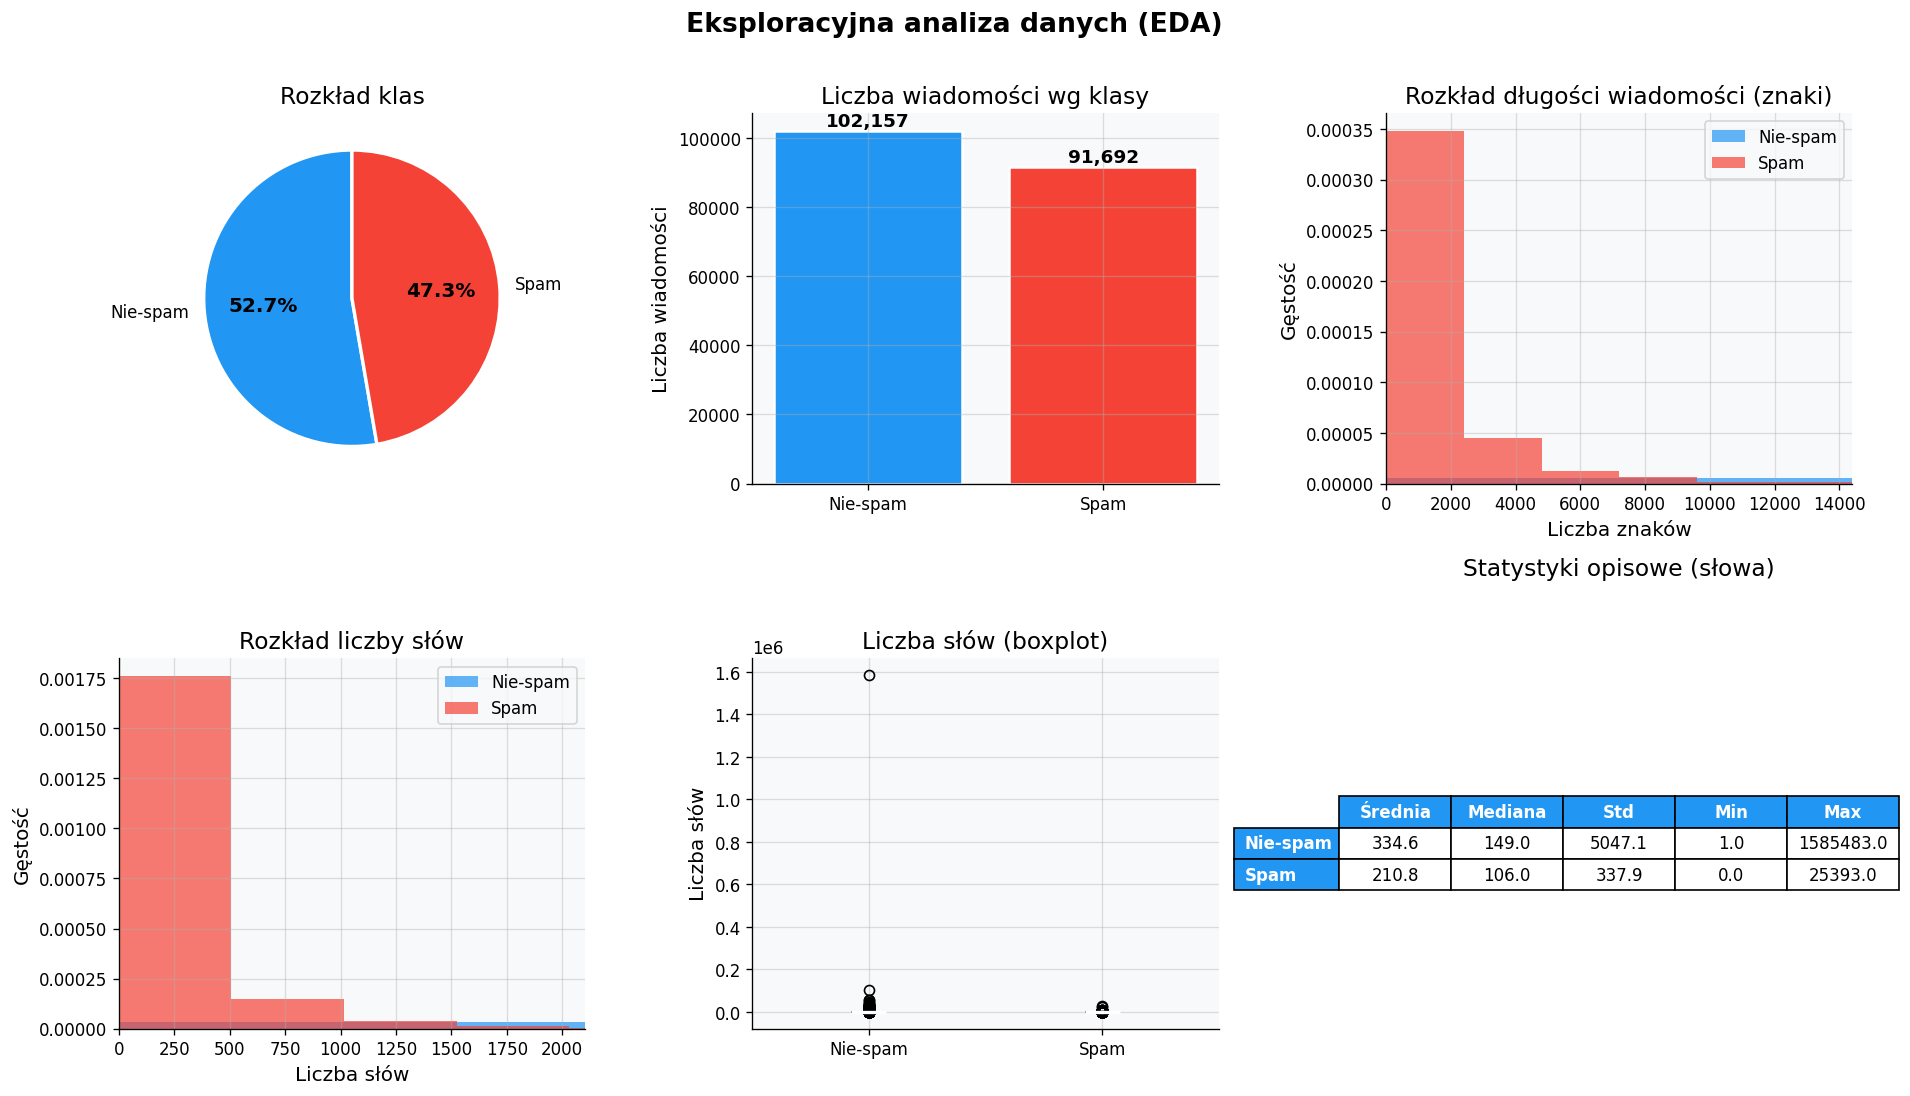

Zapisano: eda_overview.png


In [8]:
# --- Długość tekstów ---
data['length'] = data['text'].apply(len)
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Eksploracyjna analiza danych (EDA)', fontsize=16, fontweight='bold', y=1.01)

# 1. Rozkład klas (Pie)
ax = axes[0, 0]
class_counts = y.value_counts()
wedges, texts, autotexts = ax.pie(
    class_counts,
    labels=['Nie-spam', 'Spam'],
    autopct='%1.1f%%',
    colors=[PALETTE[0], PALETTE[1]],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Rozkład klas')

# 2. Rozkład klas (Bar)
ax = axes[0, 1]
bars = ax.bar(['Nie-spam', 'Spam'], class_counts.values, color=PALETTE[:2], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Liczba wiadomości wg klasy')
ax.set_ylabel('Liczba wiadomości')

# 3. Rozkład długości tekstu (znaki)
ax = axes[0, 2]
for label, name, color in zip([0, 1], ['Nie-spam', 'Spam'], PALETTE[:2]):
    ax.hist(data[y == label]['length'], bins=60, alpha=0.7, label=name, color=color, density=True)
ax.set_title('Rozkład długości wiadomości (znaki)')
ax.set_xlabel('Liczba znaków')
ax.set_ylabel('Gęstość')
ax.legend()
ax.set_xlim(0, data['length'].quantile(0.99))

# 4. Rozkład liczby słów
ax = axes[1, 0]
for label, name, color in zip([0, 1], ['Nie-spam', 'Spam'], PALETTE[:2]):
    ax.hist(data[y == label]['word_count'], bins=50, alpha=0.7, label=name, color=color, density=True)
ax.set_title('Rozkład liczby słów')
ax.set_xlabel('Liczba słów')
ax.set_ylabel('Gęstość')
ax.legend()
ax.set_xlim(0, data['word_count'].quantile(0.99))

# 5. Boxplot długości
ax = axes[1, 1]
data_box = [data[y == 0]['word_count'].values, data[y == 1]['word_count'].values]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Nie-spam', 'Spam'],
                medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE[:2]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Liczba słów (boxplot)')
ax.set_ylabel('Liczba słów')

# 6. Statystyki opisowe
ax = axes[1, 2]
ax.axis('off')
stats = data.groupby('label')['word_count'].describe()[['mean','50%','std','min','max']].round(1)
stats.index = ['Nie-spam', 'Spam']
stats.columns = ['Średnia', 'Mediana', 'Std', 'Min', 'Max']
table = ax.table(cellText=stats.values, rowLabels=stats.index,
                 colLabels=stats.columns, loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (r, c), cell in table.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor('#2196F3')
        cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Statystyki opisowe (słowa)', pad=50)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: eda_overview.png")

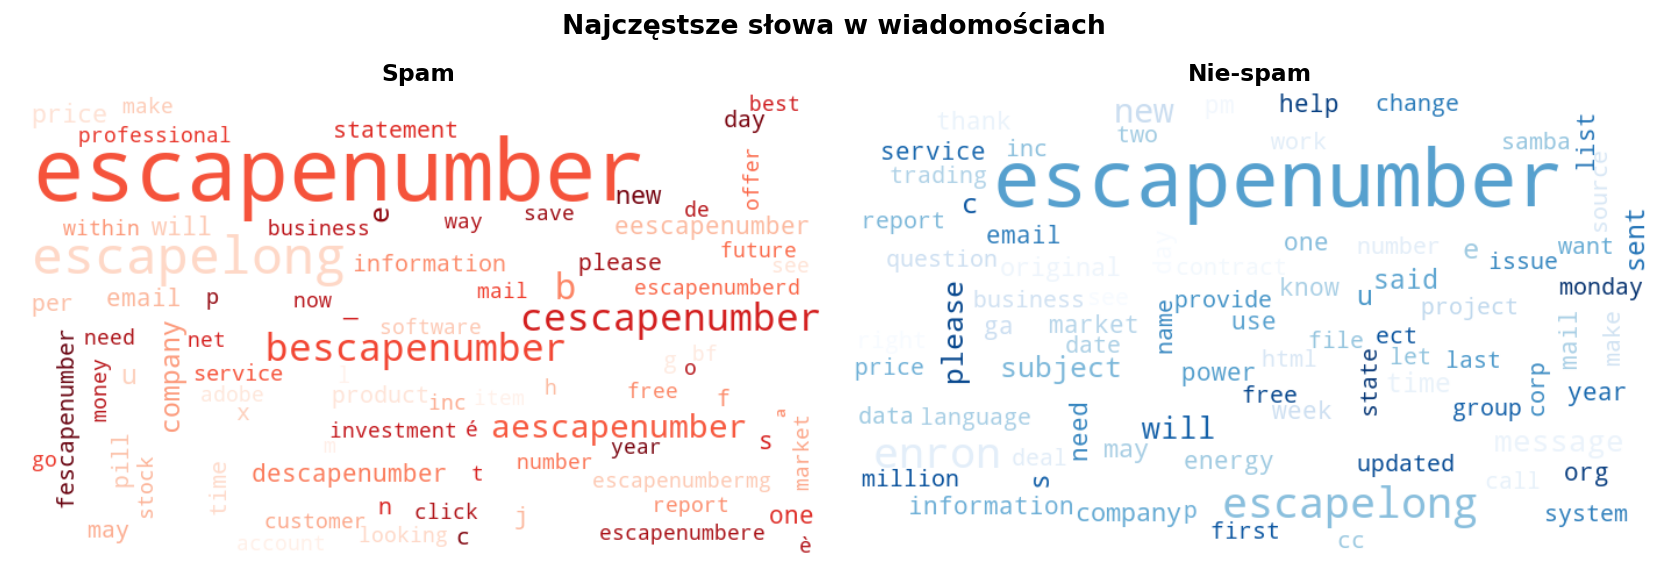

WordCloud zapisany


In [9]:
# --- WordCloud spam vs ham ---
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label, title, cmap in zip(
        axes, [1, 0], ['Spam', 'Nie-spam'], ['Reds', 'Blues']
    ):
        text_corpus = ' '.join(data[y == label]['text'].values)
        wc = WordCloud(width=700, height=400, max_words=80,
                       background_color='white', colormap=cmap,
                       collocations=False).generate(text_corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
    fig.suptitle('Najczęstsze słowa w wiadomościach', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("WordCloud zapisany")
except ImportError:
    print("Zainstaluj wordcloud:  !pip install wordcloud")


## 5. Podział danych i wektoryzacja TF-IDF

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Zbiór treningowy: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Zbiór testowy:    {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nSpam w train: {y_train.mean()*100:.1f}%")
print(f"Spam w test:  {y_test.mean()*100:.1f}%")

X_clean = data_clean['text']
y_clean = data_clean['label'].apply(lambda x: 1 if x == 'Spam' else 0)
_idx_tr, _idx_te = train_test_split(
    np.arange(len(X_clean)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clean,
)
X_train_full_BERT = X_clean.iloc[_idx_tr].reset_index(drop=True)
y_train_full_BERT = y_clean.iloc[_idx_tr].reset_index(drop=True)
print(f"\nFull BERT: {len(X_train_full_BERT):,}")


Zbiór treningowy: 155,079 (80.0%)
Zbiór testowy:    38,770  (20.0%)

Spam w train: 47.3%
Spam w test:  47.3%

Full BERT: 155,079


In [11]:
import json
import os
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression  # lub Twój docelowy model
from sklearn.metrics import f1_score, accuracy_score

# ──────────────────────────────────────────────
# KONFIGURACJA
# ──────────────────────────────────────────────
RESULTS_FILE = "tfidf_ngram_results.json"

NGRAM_CONFIGS = [
    (1, 1),   # tylko unigramy
    (1, 2),   # uni + bigramy
    (1, 3),   # uni + bi + trigramy
    (2, 2),   # tylko bigramy
    (2, 3),   # bi + trigramy
]

TFIDF_BASE_PARAMS = dict(
    stop_words=STOP_WORDS,
    max_features=15000,
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

# ──────────────────────────────────────────────
# ZAPIS / ODCZYT CACHE
# ──────────────────────────────────────────────
def load_results(path: str) -> dict:
    """Wczytuje poprzednie wyniki z pliku JSON (jeśli istnieje)."""
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        print(f"[cache] Wczytano {len(data)} wcześniej obliczonych konfiguracji z '{path}'")
        return data
    return {}

def save_results(path: str, results: dict) -> None:
    """Zapisuje wyniki do pliku JSON."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"[cache] Zapisano wyniki do '{path}'")

def config_key(ngram_range: tuple) -> str:
    return f"ngram_{ngram_range[0]}_{ngram_range[1]}"

# ──────────────────────────────────────────────
# BENCHMARK
# ──────────────────────────────────────────────
all_results = load_results(RESULTS_FILE)

for ngram_range in NGRAM_CONFIGS:
    key = config_key(ngram_range)

    # --- przywróć z cache, jeśli już obliczone ---
    if key in all_results:
        r = all_results[key]
        print(f"[skip]  ngram_range={ngram_range} — wynik z cache: "
              f"F1={r['f1']:.4f}, Acc={r['accuracy']:.4f}")
        continue

    print(f"\n[run]   ngram_range={ngram_range} ...")
    t0 = time.perf_counter()

    # Budowa TF-IDF
    tfidf = TfidfVectorizer(**TFIDF_BASE_PARAMS, ngram_range=ngram_range)
    X_tr  = tfidf.fit_transform(X_train)
    X_te  = tfidf.transform(X_test)

    # Szybki model do porównania (zamień na swój docelowy)
    clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", n_jobs=-1)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    elapsed = time.perf_counter() - t0

    result = {
        "ngram_range":  list(ngram_range),
        "n_features":   X_tr.shape[1],
        "density_pct":  round(X_tr.nnz / (X_tr.shape[0] * X_tr.shape[1]) * 100, 4),
        "f1":           round(f1_score(y_test, y_pred, average="weighted"), 6),
        "accuracy":     round(accuracy_score(y_test, y_pred), 6),
        "time_s":       round(elapsed, 2),
    }

    all_results[key] = result
    save_results(RESULTS_FILE, all_results)  # zapis po każdej konfiguracji

    print(f"        features={result['n_features']:>6}, "
          f"density={result['density_pct']:.3f}%, "
          f"F1={result['f1']:.4f}, Acc={result['accuracy']:.4f}, "
          f"czas={result['time_s']:.1f}s")

# ──────────────────────────────────────────────
# PODSUMOWANIE I WYBÓR NAJLEPSZEGO
# ──────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'ngram_range':<14} {'features':>8} {'density%':>9} "
      f"{'F1':>8} {'Accuracy':>9} {'czas(s)':>8}")
print("-"*65)

best_key = max(all_results, key=lambda k: all_results[k]["f1"])

for key, r in sorted(all_results.items()):
    marker = " ◄ BEST" if key == best_key else ""
    print(f"({r['ngram_range'][0]},{r['ngram_range'][1]}){'':<10} "
          f"{r['n_features']:>8} "
          f"{r['density_pct']:>8.3f}% "
          f"{r['f1']:>8.4f} "
          f"{r['accuracy']:>9.4f} "
          f"{r['time_s']:>7.1f}s"
          f"{marker}")

print("="*65)
best = all_results[best_key]
print(f"\nNajlepsza konfiguracja: ngram_range=({best['ngram_range'][0]},{best['ngram_range'][1]})")
print(f"  F1 = {best['f1']:.4f}   Accuracy = {best['accuracy']:.4f}")

# ──────────────────────────────────────────────
# BUDOWA FINALNEGO TF-IDF Z NAJLEPSZĄ KONFIGURACJĄ
# ──────────────────────────────────────────────
best_ngram = tuple(best["ngram_range"])
tfidf = TfidfVectorizer(**TFIDF_BASE_PARAMS, ngram_range=best_ngram)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nFinalny TF-IDF (train): {X_train_tfidf.shape}")
print(f"Finalny TF-IDF (test):  {X_test_tfidf.shape}")
print(f"Gęstość macierzy:       {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])*100:.3f}%")

[cache] Wczytano 5 wcześniej obliczonych konfiguracji z 'tfidf_ngram_results.json'
[skip]  ngram_range=(1, 1) — wynik z cache: F1=0.9783, Acc=0.9783
[skip]  ngram_range=(1, 2) — wynik z cache: F1=0.9789, Acc=0.9789
[skip]  ngram_range=(1, 3) — wynik z cache: F1=0.9783, Acc=0.9783
[skip]  ngram_range=(2, 2) — wynik z cache: F1=0.9487, Acc=0.9486
[skip]  ngram_range=(2, 3) — wynik z cache: F1=0.9391, Acc=0.9390

ngram_range    features  density%       F1  Accuracy  czas(s)
-----------------------------------------------------------------
(1,1)              15000    0.533%   0.9783    0.9783    32.9s
(1,2)              15000    0.634%   0.9789    0.9789    94.9s ◄ BEST
(1,3)              15000    0.677%   0.9783    0.9783   168.8s
(2,2)              15000    0.196%   0.9487    0.9486    70.5s
(2,3)              15000    0.264%   0.9391    0.9390   146.8s

Najlepsza konfiguracja: ngram_range=(1,2)
  F1 = 0.9789   Accuracy = 0.9789

Finalny TF-IDF (train): (155079, 15000)
Finalny TF-IDF (te

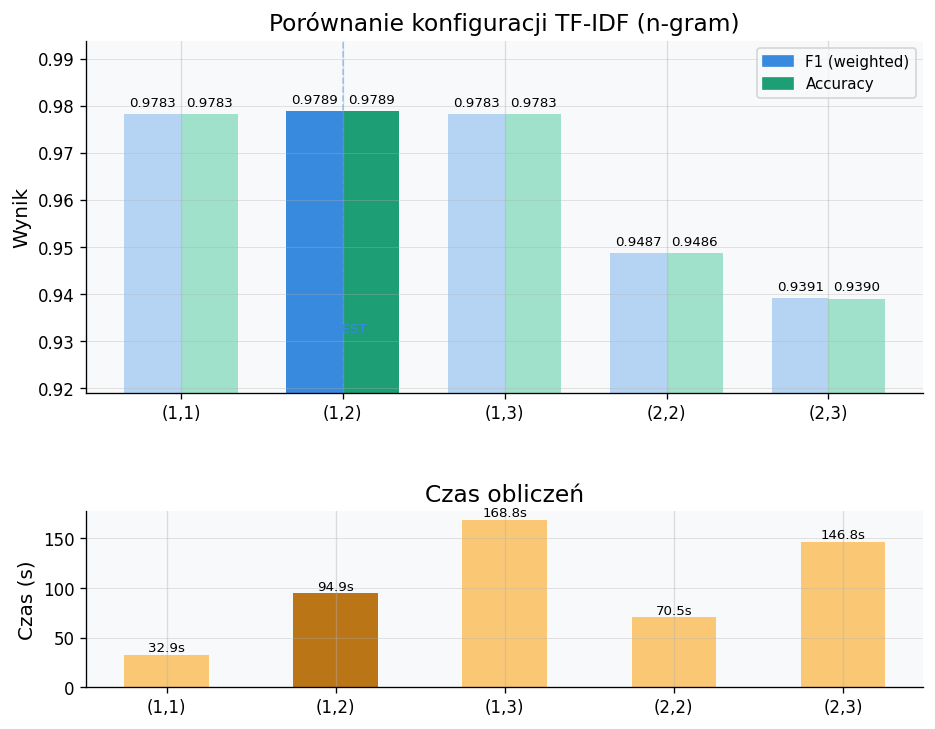

Wykres zapisany jako tfidf_ngram_comparison.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ──────────────────────────────────────────────
# DANE Z WYNIKÓW
# ──────────────────────────────────────────────
keys    = sorted(all_results.keys())
labels  = [f"({r['ngram_range'][0]},{r['ngram_range'][1]})" for r in [all_results[k] for k in keys]]
f1_vals = [all_results[k]["f1"]       for k in keys]
ac_vals = [all_results[k]["accuracy"] for k in keys]
t_vals  = [all_results[k]["time_s"]   for k in keys]

best_idx = int(np.argmax(f1_vals))
x = np.arange(len(labels))
w = 0.35

# ──────────────────────────────────────────────
# WYKRES
# ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={"height_ratios": [2, 1]})
fig.subplots_adjust(hspace=0.45)

# --- górny: F1 i Accuracy ---
bars_f1 = ax1.bar(x - w/2, f1_vals, w, label="F1 (weighted)",
                  color=["#378ADD" if i == best_idx else "#B5D4F4" for i in range(len(x))])
bars_ac = ax1.bar(x + w/2, ac_vals, w, label="Accuracy",
                  color=["#1D9E75" if i == best_idx else "#9FE1CB" for i in range(len(x))])

# wartości nad słupkami
for bar in [*bars_f1, *bars_ac]:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

# oznaczenie najlepszego
ax1.axvline(x[best_idx], color="#378ADD", linewidth=1, linestyle="--", alpha=0.4)
ax1.text(x[best_idx], ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else min(f1_vals) - 0.005,
         "▲ BEST", ha="center", va="top", fontsize=8, color="#378ADD")

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Wynik")
ax1.set_title("Porównanie konfiguracji TF-IDF (n-gram)")
ax1.set_ylim(min(f1_vals) - 0.02, max(f1_vals) + 0.015)
ax1.legend(handles=[
    mpatches.Patch(color="#378ADD", label="F1 (weighted)"),
    mpatches.Patch(color="#1D9E75", label="Accuracy"),
], fontsize=9)
ax1.grid(axis="y", linewidth=0.4, alpha=0.5)
ax1.spines[["top", "right"]].set_visible(False)

# --- dolny: czas ---
bars_t = ax2.bar(x, t_vals, 0.5,
                 color=["#BA7517" if i == best_idx else "#FAC775" for i in range(len(x))])

for bar in bars_t:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Czas (s)")
ax2.set_title("Czas obliczeń")
ax2.grid(axis="y", linewidth=0.4, alpha=0.5)
ax2.spines[["top", "right"]].set_visible(False)

plt.savefig("tfidf_ngram_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany jako tfidf_ngram_comparison.png")

In [13]:
# --- Test wpływu max_features na jakość klasyfikacji ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

max_features_values = [1000, 3000, 5000, 8000, 10000, 15000, 20000, None]

results = []

for mf in max_features_values:
    tfidf_test = TfidfVectorizer(
        stop_words=STOP_WORDS,
        max_features=mf,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95
    )

    X_train_tmp = tfidf_test.fit_transform(X_train)
    X_test_tmp  = tfidf_test.transform(X_test)

    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_train_tmp, y_train)
    y_pred = clf.predict(X_test_tmp)

    f1 = f1_score(y_test, y_pred)
    n_features = X_train_tmp.shape[1]

    results.append({
        "max_features": mf if mf is not None else n_features,
        "rzeczywista_liczba_cech": n_features,
        "f1_score": f1
    })

    print(f"max_features={mf!s:>6} -> cechy: {n_features:>6}, F1: {f1:.4f}")

df_results = pd.DataFrame(results)
df_results

max_features=  1000 -> cechy:   1000, F1: 0.9487
max_features=  3000 -> cechy:   3000, F1: 0.9659
max_features=  5000 -> cechy:   5000, F1: 0.9715
max_features=  8000 -> cechy:   8000, F1: 0.9753
max_features= 10000 -> cechy:  10000, F1: 0.9761
max_features= 15000 -> cechy:  15000, F1: 0.9779
max_features= 20000 -> cechy:  20000, F1: 0.9783
max_features=  None -> cechy: 3211645, F1: 0.9797


,max_features,rzeczywista_liczba_cech,f1_score
0,1000,1000,0.948662
1,3000,3000,0.965864
2,5000,5000,0.971504
3,8000,8000,0.975323
4,10000,10000,0.976085
5,15000,15000,0.977856
6,20000,20000,0.978313
7,3211645,3211645,0.979693


In [14]:
# --- TF-IDF z optymalnymi parametrami ---
tfidf = TfidfVectorizer(
    stop_words=STOP_WORDS,
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,       # log(tf+1) — lepsze dla tekstu
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Macierz TF-IDF (train): {X_train_tfidf.shape}")
print(f"Macierz TF-IDF (test):  {X_test_tfidf.shape}")
print(f"Gęstość macierzy:       {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])*100:.3f}%")


Macierz TF-IDF (train): (155079, 15000)
Macierz TF-IDF (test):  (38770, 15000)
Gęstość macierzy:       0.634%


## 6. Modele klasyczne — strojenie hiperparametrów (GridSearchCV)

Dla każdego modelu przeprowadzamy przeszukiwanie siatki hiperparametrów z kroswalidacją stratyfikowaną (5 foldów), optymalizując metrykę **F1-score**.


Ładuję zapisany model Naive Bayes...
   (czas trenowania z cache: 4.0s)

=== Naive Bayes ===
Najlepsze parametry: {'alpha': 1e-30}
CV F1 (train):       0.9499
F1 (test):           0.9495
Czas trenowania:     4.05s
Czas predykcji:      15.1ms


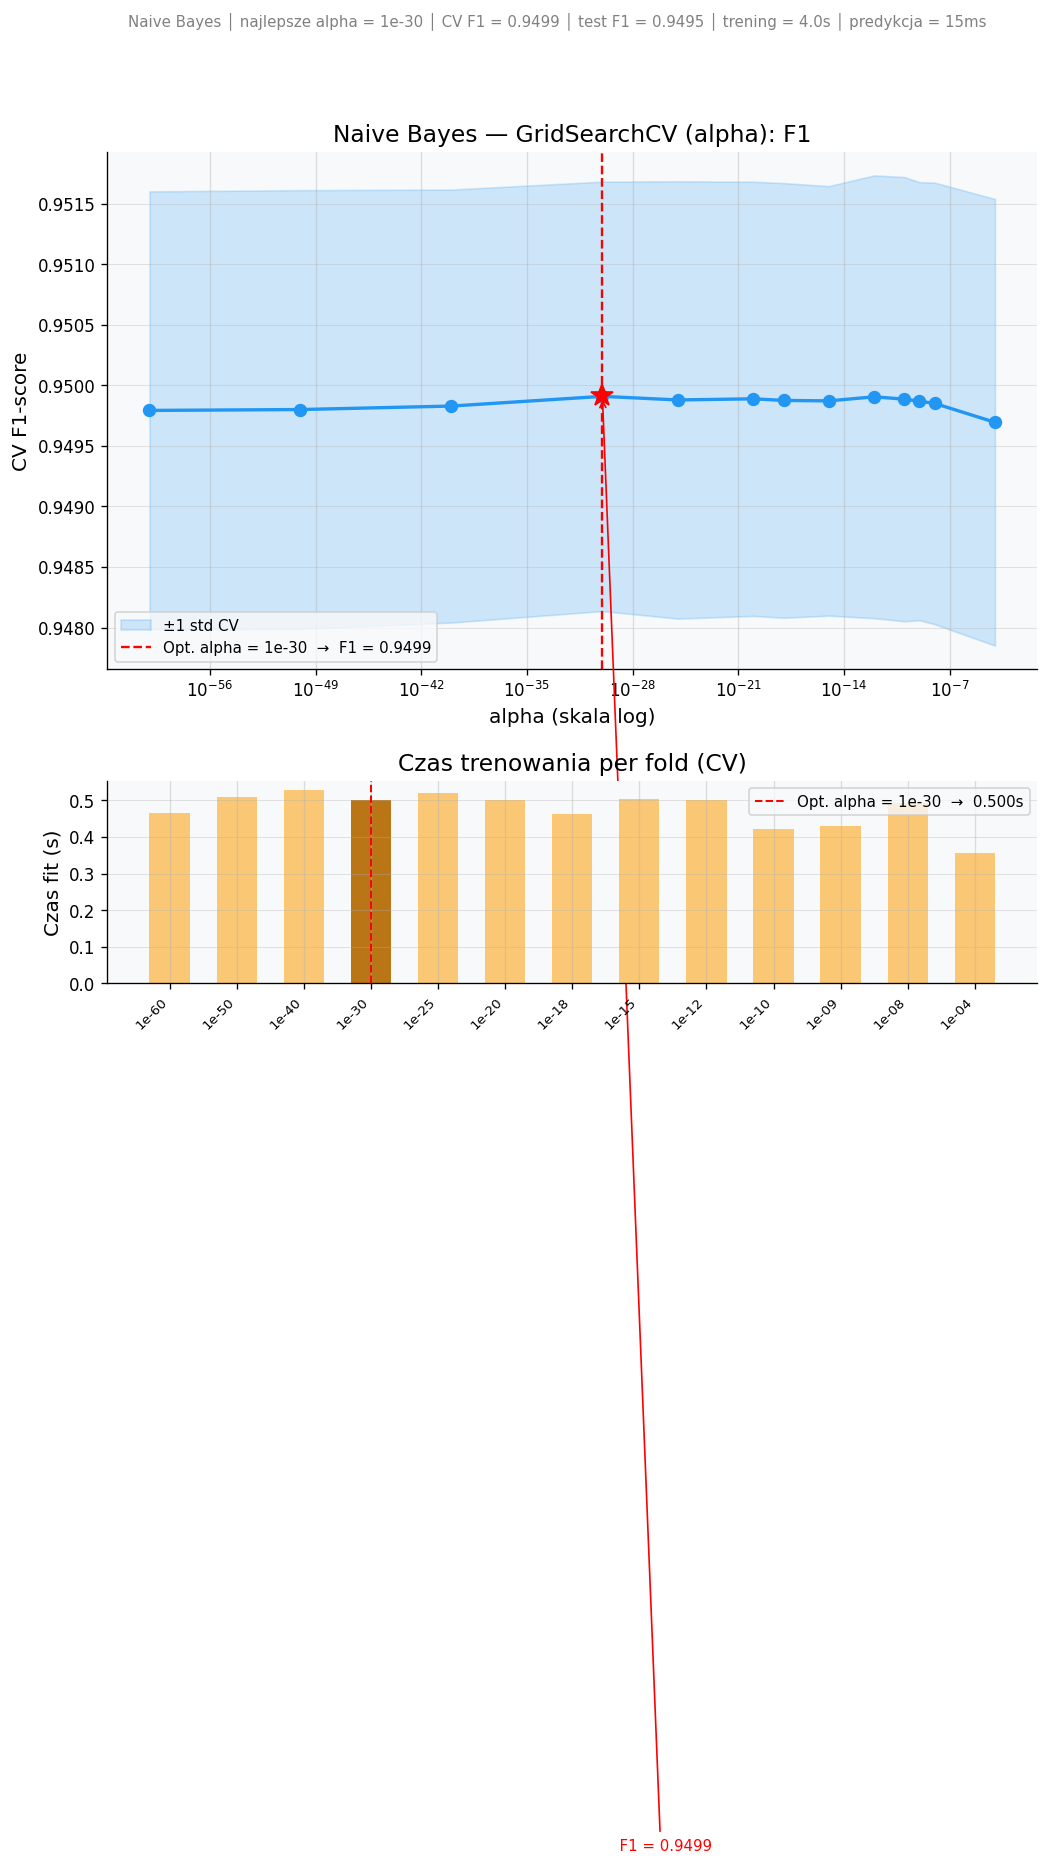

Wykres zapisany jako gridsearch_nb.png


In [15]:
# ════════════════════════════════════════════════════════════
# Naive Bayes — strojenie alpha (siła wygładzania Laplace'a)
# ════════════════════════════════════════════════════════════
from sklearn.model_selection import GridSearchCV
import joblib, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

param_grid_nb = {
    'alpha': [
        1e-60, 1e-50, 1e-40, 1e-30, 1e-25, 1e-20, 1e-18, 1e-15, 1e-12, 1e-10, 1e-9, 1e-8,
        0.0001,
    ]
}

if os.path.exists('gs_nb.pkl'):
    print("Ładuję zapisany model Naive Bayes...")
    loaded_nb = joblib.load('gs_nb.pkl')
    if isinstance(loaded_nb, tuple):
        gs_nb, fit_time = loaded_nb
    else:
        gs_nb, fit_time = loaded_nb, np.nan
    print(f"   (czas trenowania z cache: {fit_time:.1f}s)")
else:
    print("Trenuję model Naive Bayes...")
    gs_nb = GridSearchCV(
        MultinomialNB(), param_grid_nb,
        scoring='f1', cv=CV_FOLDS, n_jobs=-1, verbose=0
    )
    t0 = time.perf_counter()
    gs_nb.fit(X_train_tfidf, y_train)
    fit_time = time.perf_counter() - t0
    joblib.dump((gs_nb, fit_time), 'gs_nb.pkl')
    print(f"Model zapisany. Czas trenowania: {fit_time:.1f}s")

best_nb = gs_nb.best_estimator_

t0 = time.perf_counter()
y_nb = best_nb.predict(X_test_tfidf)
pred_time = time.perf_counter() - t0

f1_test = f1_score(y_test, y_nb)

print("\n=== Naive Bayes ===")
print(f"Najlepsze parametry: {gs_nb.best_params_}")
print(f"CV F1 (train):       {gs_nb.best_score_:.4f}")
print(f"F1 (test):           {f1_test:.4f}")
print(f"Czas trenowania:     {fit_time:.2f}s")
print(f"Czas predykcji:      {pred_time*1000:.1f}ms")

# ──────────────────────────────────────────────
# DANE DO WYKRESÓW
# ──────────────────────────────────────────────
cv_results_nb  = pd.DataFrame(gs_nb.cv_results_)
alpha_values   = sorted(param_grid_nb['alpha'])

mean_scores = [cv_results_nb.loc[cv_results_nb['param_alpha'] == a, 'mean_test_score'].values[0] for a in alpha_values]
std_scores  = [cv_results_nb.loc[cv_results_nb['param_alpha'] == a, 'std_test_score'].values[0]  for a in alpha_values]
mean_times  = [cv_results_nb.loc[cv_results_nb['param_alpha'] == a, 'mean_fit_time'].values[0]   for a in alpha_values]

best_alpha  = gs_nb.best_params_['alpha']
best_idx    = alpha_values.index(best_alpha)
best_f1     = mean_scores[best_idx]
best_time   = mean_times[best_idx]

# ──────────────────────────────────────────────
# WYKRES
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(10, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

ax1 = fig.add_subplot(gs[0:2])   # F1 — duży
ax2 = fig.add_subplot(gs[2])     # czas — mały

# --- F1 ---
ax1.semilogx(alpha_values, mean_scores, 'o-', color=PALETTE[0], linewidth=2, markersize=7, zorder=3)
ax1.fill_between(alpha_values,
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores),
                 alpha=0.2, color=PALETTE[0], label="±1 std CV")

ax1.axvline(best_alpha, color='red', linestyle='--', linewidth=1.4,
            label=f"Opt. alpha = {best_alpha:.0e}  →  F1 = {best_f1:.4f}")
ax1.plot(best_alpha, best_f1, '*', color='red', markersize=14, zorder=5)
ax1.annotate(f"  F1 = {best_f1:.4f}", xy=(best_alpha, best_f1),
             xytext=(best_alpha * 3, best_f1 - 0.012),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax1.set_xlabel('alpha (skala log)')
ax1.set_ylabel('CV F1-score')
ax1.set_title('Naive Bayes — GridSearchCV (alpha): F1')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linewidth=0.4, alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# --- CZAS ---
colors_t = ['#BA7517' if a == best_alpha else '#FAC775' for a in alpha_values]
ax2.bar(range(len(alpha_values)), mean_times, color=colors_t, width=0.6)
ax2.set_xticks(range(len(alpha_values)))
ax2.set_xticklabels([f"{a:.0e}" for a in alpha_values], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Czas fit (s)')
ax2.set_title('Czas trenowania per fold (CV)')
ax2.axvline(best_idx, color='red', linestyle='--', linewidth=1.2,
            label=f"Opt. alpha = {best_alpha:.0e}  →  {best_time:.3f}s")
ax2.legend(fontsize=9)
ax2.grid(axis='y', linewidth=0.4, alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)

# --- PODSUMOWANIE W TYTULE ---
fig.suptitle(
    f"Naive Bayes │ najlepsze alpha = {best_alpha:.0e} │ "
    f"CV F1 = {best_f1:.4f} │ test F1 = {f1_test:.4f} │ "
    f"trening = {fit_time:.1f}s │ predykcja = {pred_time*1000:.0f}ms",
    fontsize=9, color='gray', y=1.01
)

plt.savefig('gridsearch_nb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako gridsearch_nb.png")

Ładuję zapisany model Logistic Regression...
   (czas trenowania z cache: 122.7s)

=== Logistic Regression ===
Najlepsze parametry: {'C': 90.0, 'penalty': 'l2', 'solver': 'liblinear'}
CV F1 (train):       0.9844
F1 (test):           0.9846
Czas trenowania:     122.65s
Czas predykcji:      6.6ms


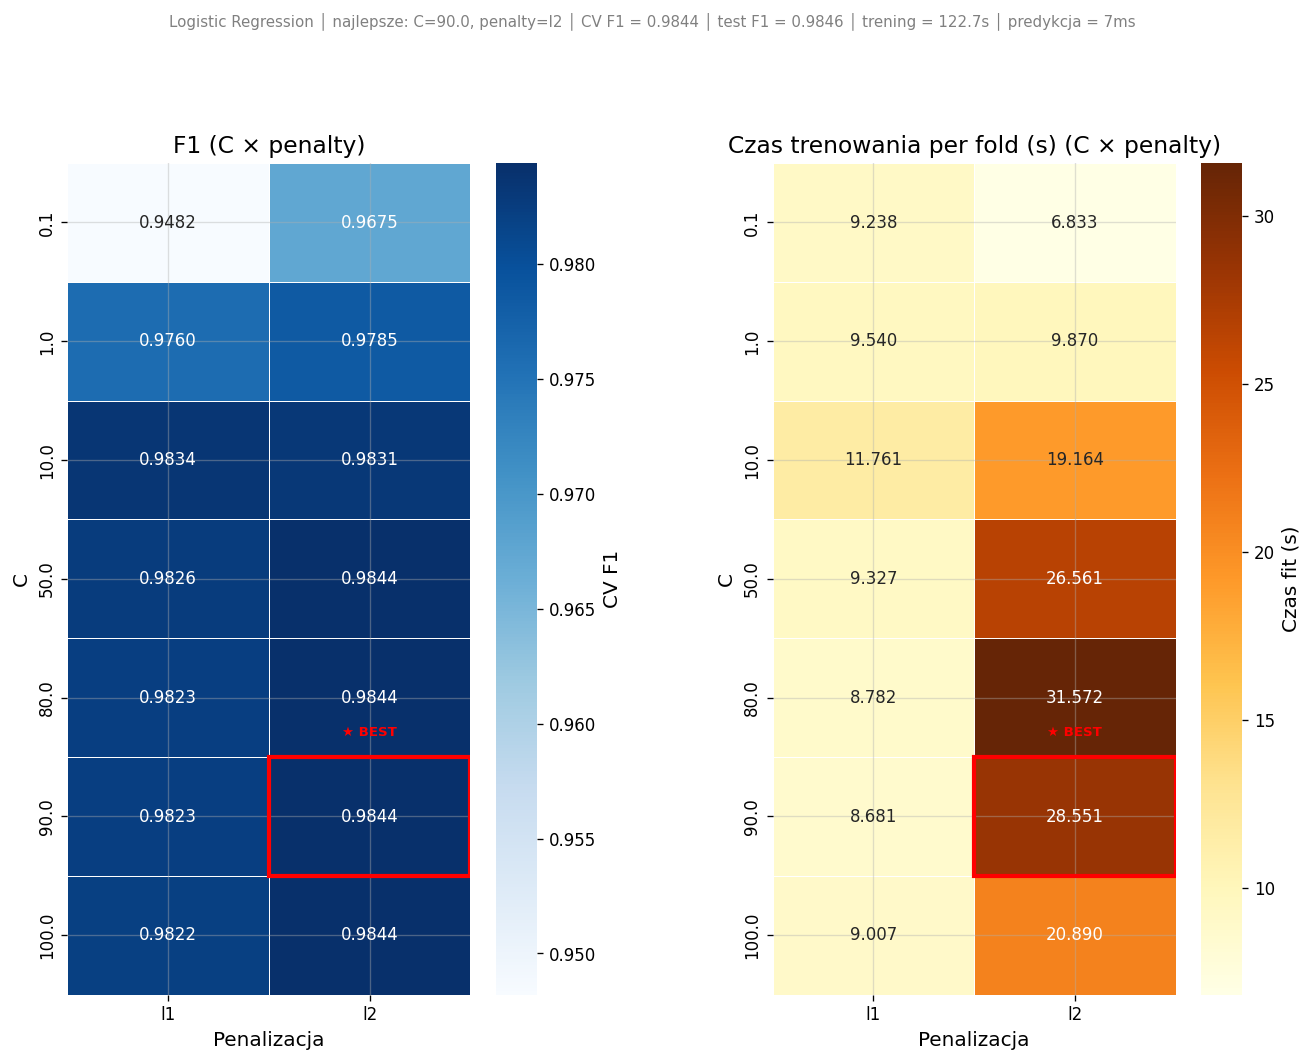

Wykres zapisany jako gridsearch_lr.png


In [16]:
# ════════════════════════════════════════════════════════════
# Logistic Regression — strojenie C i penalizacji
# ════════════════════════════════════════════════════════════
import joblib, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

param_grid_lr = {
    'C':        [0.1, 1.0, 10.0, 50.0, 80.0, 90.0, 100.0],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear']
}

if os.path.exists('gs_lr.pkl'):
    print("Ładuję zapisany model Logistic Regression...")
    loaded_lr = joblib.load('gs_lr.pkl')
    if isinstance(loaded_lr, tuple):
        gs_lr, fit_time = loaded_lr
    else:
        gs_lr, fit_time = loaded_lr, np.nan
    print(f"   (czas trenowania z cache: {fit_time:.1f}s)")
else:
    print("Trenuję model Logistic Regression...")
    gs_lr = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        param_grid_lr,
        scoring='f1', cv=CV_FOLDS, n_jobs=-1
    )
    t0 = time.perf_counter()
    gs_lr.fit(X_train_tfidf, y_train)
    fit_time = time.perf_counter() - t0
    joblib.dump((gs_lr, fit_time), 'gs_lr.pkl')
    print(f"Model zapisany. Czas trenowania: {fit_time:.1f}s")

best_lr = gs_lr.best_estimator_

t0 = time.perf_counter()
y_lr = best_lr.predict(X_test_tfidf)
pred_time = time.perf_counter() - t0

f1_test = f1_score(y_test, y_lr)
best_C       = gs_lr.best_params_['C']
best_penalty = gs_lr.best_params_['penalty']

print("\n=== Logistic Regression ===")
print(f"Najlepsze parametry: {gs_lr.best_params_}")
print(f"CV F1 (train):       {gs_lr.best_score_:.4f}")
print(f"F1 (test):           {f1_test:.4f}")
print(f"Czas trenowania:     {fit_time:.2f}s")
print(f"Czas predykcji:      {pred_time*1000:.1f}ms")

# ──────────────────────────────────────────────
# DANE DO WYKRESÓW
# ──────────────────────────────────────────────
cv_df = pd.DataFrame(gs_lr.cv_results_)

pivot_f1   = cv_df.pivot_table(index='param_C', columns='param_penalty', values='mean_test_score')
pivot_time = cv_df.pivot_table(index='param_C', columns='param_penalty', values='mean_fit_time')

# ──────────────────────────────────────────────
# WYKRES
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

ax1 = fig.add_subplot(gs[0])   # heatmapa F1
ax2 = fig.add_subplot(gs[1])   # heatmapa czasu

# --- F1 ---
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='Blues',
            ax=ax1, linewidths=0.5, cbar_kws={'label': 'CV F1'})

# oznacz najlepszą komórkę
best_row = list(pivot_f1.index).index(best_C)
best_col = list(pivot_f1.columns).index(best_penalty)
ax1.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax1.text(best_col + 0.5, best_row - 0.15, '★ BEST',
         ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax1.set_title('F1 (C × penalty)')
ax1.set_xlabel('Penalizacja')
ax1.set_ylabel('C')

# --- CZAS ---
sns.heatmap(pivot_time, annot=True, fmt='.3f', cmap='YlOrBr',
            ax=ax2, linewidths=0.5, cbar_kws={'label': 'Czas fit (s)'})

# oznacz najlepszą komórkę też na wykresie czasu
ax2.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax2.text(best_col + 0.5, best_row - 0.15, '★ BEST',
         ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax2.set_title('Czas trenowania per fold (s) (C × penalty)')
ax2.set_xlabel('Penalizacja')
ax2.set_ylabel('C')

fig.suptitle(
    f"Logistic Regression │ najlepsze: C={best_C}, penalty={best_penalty} │ "
    f"CV F1 = {gs_lr.best_score_:.4f} │ test F1 = {f1_test:.4f} │ "
    f"trening = {fit_time:.1f}s │ predykcja = {pred_time*1000:.0f}ms",
    fontsize=9, color='gray', y=1.02
)

plt.savefig('gridsearch_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako gridsearch_lr.png")

Ładuję zapisany model SVM...
   (czas trenowania z cache: 173.7s)

=== SVM ===
Najlepsze parametry: {'estimator__C': 10.0}
CV F1 (train):       0.9841
F1 (test):           0.9848
Czas trenowania:     173.72s
Czas predykcji:      48.5ms


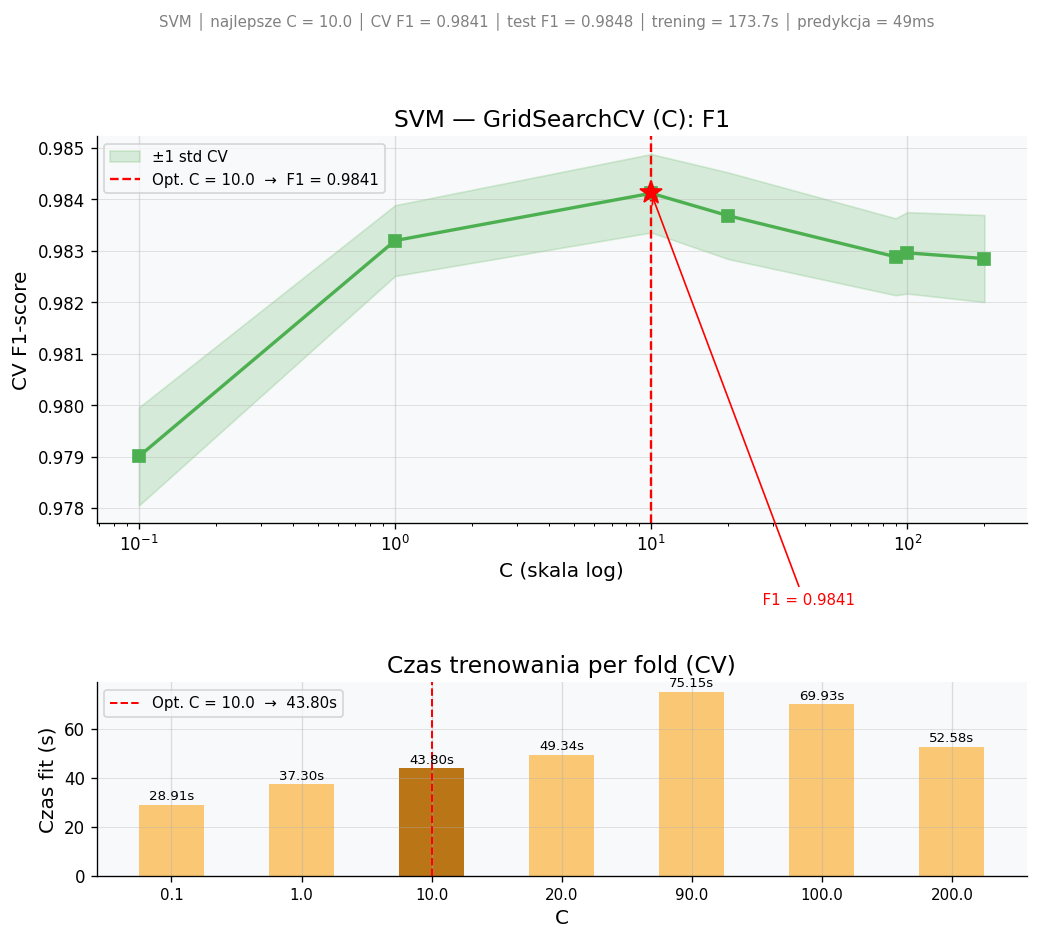

Wykres zapisany jako gridsearch_svm.png


In [17]:
# ════════════════════════════════════════════════════════════
# Linear SVM — strojenie C
# ════════════════════════════════════════════════════════════
import joblib, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

param_grid_svm = {'estimator__C': [0.1, 1.0, 10.0, 20.0, 90.0, 100.0, 200.0]}

if os.path.exists('gs_svm.pkl'):
    print("Ładuję zapisany model SVM...")
    loaded_svm = joblib.load('gs_svm.pkl')
    if isinstance(loaded_svm, tuple):
        gs_svm, fit_time = loaded_svm
    else:
        gs_svm, fit_time = loaded_svm, np.nan
    print(f"   (czas trenowania z cache: {fit_time:.1f}s)")
else:
    print("Trenuję model SVM...")
    gs_svm = GridSearchCV(
        CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=RANDOM_STATE)),
        param_grid_svm,
        scoring='f1', cv=CV_FOLDS, n_jobs=-1
    )
    t0 = time.perf_counter()
    gs_svm.fit(X_train_tfidf, y_train)
    fit_time = time.perf_counter() - t0
    joblib.dump((gs_svm, fit_time), 'gs_svm.pkl')
    print(f"Model zapisany. Czas trenowania: {fit_time:.1f}s")

best_svm = gs_svm.best_estimator_

t0 = time.perf_counter()
y_svm = best_svm.predict(X_test_tfidf)
pred_time = time.perf_counter() - t0

f1_test  = f1_score(y_test, y_svm)
best_C   = gs_svm.best_params_['estimator__C']

print("\n=== SVM ===")
print(f"Najlepsze parametry: {gs_svm.best_params_}")
print(f"CV F1 (train):       {gs_svm.best_score_:.4f}")
print(f"F1 (test):           {f1_test:.4f}")
print(f"Czas trenowania:     {fit_time:.2f}s")
print(f"Czas predykcji:      {pred_time*1000:.1f}ms")

# ──────────────────────────────────────────────
# DANE DO WYKRESÓW
# ──────────────────────────────────────────────
cv_svm   = pd.DataFrame(gs_svm.cv_results_)
C_vals   = sorted(cv_svm['param_estimator__C'].unique())

mean_scores = [cv_svm.loc[cv_svm['param_estimator__C'] == c, 'mean_test_score'].values[0] for c in C_vals]
std_scores  = [cv_svm.loc[cv_svm['param_estimator__C'] == c, 'std_test_score'].values[0]  for c in C_vals]
mean_times  = [cv_svm.loc[cv_svm['param_estimator__C'] == c, 'mean_fit_time'].values[0]   for c in C_vals]

best_idx  = C_vals.index(best_C)
best_f1   = mean_scores[best_idx]
best_time = mean_times[best_idx]

# ──────────────────────────────────────────────
# WYKRES
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.55, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# --- F1 ---
ax1.semilogx(C_vals, mean_scores, 's-', color=PALETTE[2], linewidth=2, markersize=7, zorder=3)
ax1.fill_between(C_vals,
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores),
                 alpha=0.2, color=PALETTE[2], label="±1 std CV")

ax1.axvline(best_C, color='red', linestyle='--', linewidth=1.4,
            label=f"Opt. C = {best_C}  →  F1 = {best_f1:.4f}")
ax1.plot(best_C, best_f1, '*', color='red', markersize=14, zorder=5)
ax1.annotate(f"  F1 = {best_f1:.4f}", xy=(best_C, best_f1),
             xytext=(best_C * 2.5, best_f1 - 0.008),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax1.set_xlabel('C (skala log)')
ax1.set_ylabel('CV F1-score')
ax1.set_title('SVM — GridSearchCV (C): F1')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linewidth=0.4, alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# --- CZAS ---
colors_t = ['#BA7517' if c == best_C else '#FAC775' for c in C_vals]
bars = ax2.bar(range(len(C_vals)), mean_times, color=colors_t, width=0.5)

for bar, t in zip(bars, mean_times):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(mean_times) * 0.01,
             f"{t:.2f}s", ha='center', va='bottom', fontsize=8)

ax2.set_xticks(range(len(C_vals)))
ax2.set_xticklabels([str(c) for c in C_vals], fontsize=9)
ax2.set_xlabel('C')
ax2.set_ylabel('Czas fit (s)')
ax2.set_title('Czas trenowania per fold (CV)')
ax2.axvline(best_idx, color='red', linestyle='--', linewidth=1.2,
            label=f"Opt. C = {best_C}  →  {best_time:.2f}s")
ax2.legend(fontsize=9)
ax2.grid(axis='y', linewidth=0.4, alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f"SVM │ najlepsze C = {best_C} │ "
    f"CV F1 = {best_f1:.4f} │ test F1 = {f1_test:.4f} │ "
    f"trening = {fit_time:.1f}s │ predykcja = {pred_time*1000:.0f}ms",
    fontsize=9, color='gray', y=1.01
)

plt.savefig('gridsearch_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako gridsearch_svm.png")

Ładuję zapisany model Random Forest...
   (czas trenowania z cache: 36448.5s)

=== Random Forest ===
Najlepsze parametry: {'max_depth': 400, 'min_samples_leaf': 1, 'n_estimators': 400}
CV F1 (train):       0.9839
F1 (test):           0.9843
Czas trenowania:     36448.53s
Czas predykcji:      6610.9ms


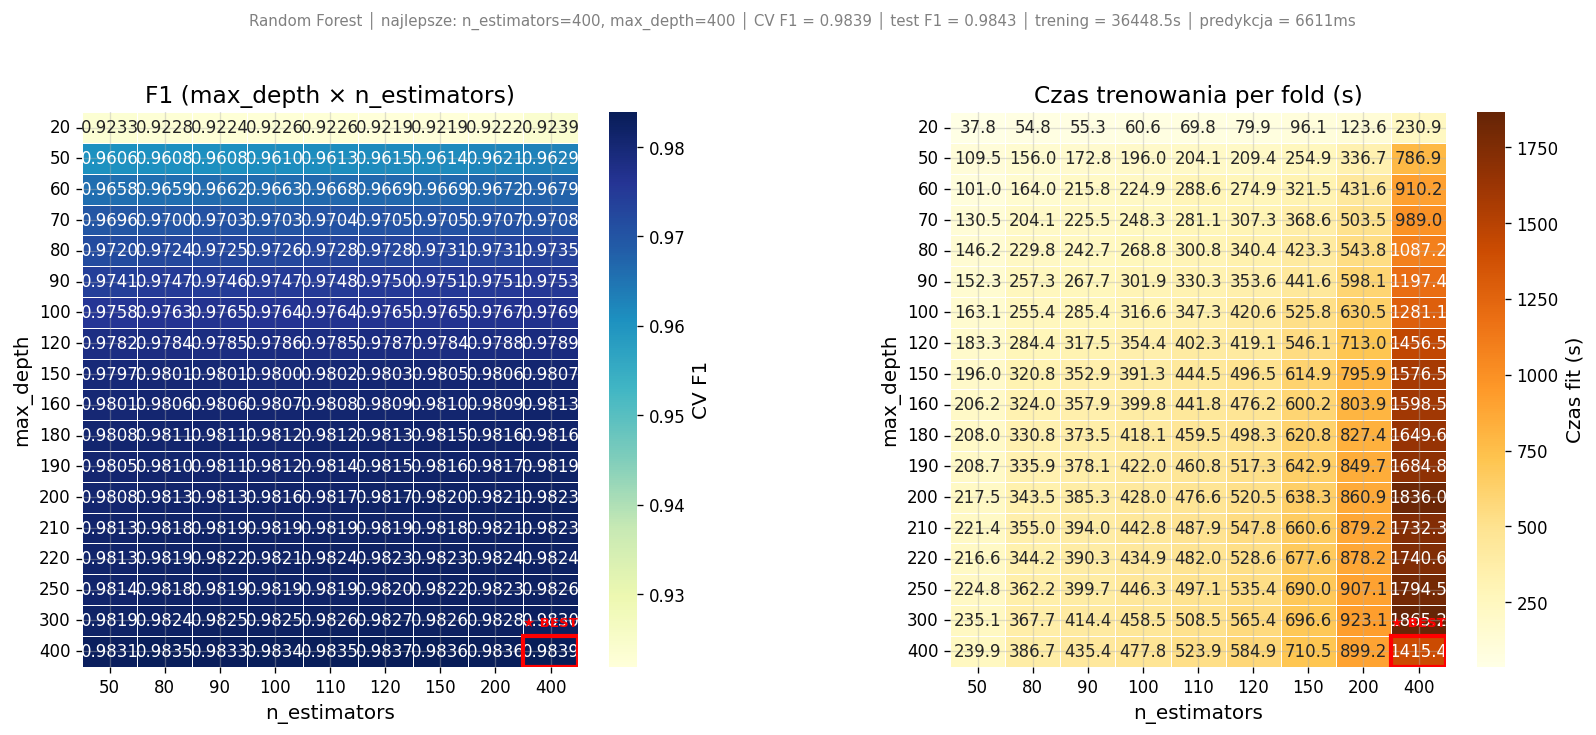

Wykres zapisany jako gridsearch_rf.png


In [18]:
# ════════════════════════════════════════════════════════════
# Random Forest — strojenie n_estimators i max_depth
# ════════════════════════════════════════════════════════════
import joblib, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

param_grid_rf = {
    'n_estimators':     [50, 80, 90, 100, 110, 120, 150, 200, 400],
    'max_depth':        [20, 50, 60, 70, 80, 90, 100, 120, 150, 160, 180, 190, 200, 210, 220, 250, 300, 400],
    'min_samples_leaf': [1]
}

if os.path.exists('gs_rf.pkl'):
    print("Ładuję zapisany model Random Forest...")
    loaded_rf = joblib.load('gs_rf.pkl')
    if isinstance(loaded_rf, tuple):
        gs_rf, fit_time = loaded_rf
    else:
        gs_rf, fit_time = loaded_rf, np.nan
    print(f"   (czas trenowania z cache: {fit_time:.1f}s)")
else:
    print("Trenuję model Random Forest...")
    gs_rf = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid_rf,
        scoring='f1', cv=CV_FOLDS, n_jobs=-1
    )
    t0 = time.perf_counter()
    gs_rf.fit(X_train_tfidf, y_train)
    fit_time = time.perf_counter() - t0
    joblib.dump((gs_rf, fit_time), 'gs_rf.pkl')
    print(f"odel zapisany. Czas trenowania: {fit_time:.1f}s")

best_rf = gs_rf.best_estimator_

t0 = time.perf_counter()
y_rf = best_rf.predict(X_test_tfidf)
pred_time = time.perf_counter() - t0

f1_test        = f1_score(y_test, y_rf)
best_n         = gs_rf.best_params_['n_estimators']
best_depth     = gs_rf.best_params_['max_depth']

print("\n=== Random Forest ===")
print(f"Najlepsze parametry: {gs_rf.best_params_}")
print(f"CV F1 (train):       {gs_rf.best_score_:.4f}")
print(f"F1 (test):           {f1_test:.4f}")
print(f"Czas trenowania:     {fit_time:.2f}s")
print(f"Czas predykcji:      {pred_time*1000:.1f}ms")

# ──────────────────────────────────────────────
# DANE DO WYKRESÓW
# ──────────────────────────────────────────────
df_rf = pd.DataFrame(gs_rf.cv_results_)

pivot_f1   = df_rf.pivot_table(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')
pivot_time = df_rf.pivot_table(index='param_max_depth', columns='param_n_estimators', values='mean_fit_time')

best_row = list(pivot_f1.index).index(best_depth)
best_col = list(pivot_f1.columns).index(best_n)
best_f1_cv    = pivot_f1.iloc[best_row, best_col]
best_time_cv  = pivot_time.iloc[best_row, best_col]

# ──────────────────────────────────────────────
# WYKRES
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# --- F1 ---
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=ax1, linewidths=0.5, cbar_kws={'label': 'CV F1'})

ax1.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax1.text(best_col + 0.5, best_row - 0.2, '★ BEST',
         ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax1.set_title('F1 (max_depth × n_estimators)')
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('max_depth')

# --- CZAS ---
sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='YlOrBr',
            ax=ax2, linewidths=0.5, cbar_kws={'label': 'Czas fit (s)'})

ax2.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax2.text(best_col + 0.5, best_row - 0.2, '★ BEST',
         ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax2.set_title('Czas trenowania per fold (s)')
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('max_depth')

fig.suptitle(
    f"Random Forest │ najlepsze: n_estimators={best_n}, max_depth={best_depth} │ "
    f"CV F1 = {best_f1_cv:.4f} │ test F1 = {f1_test:.4f} │ "
    f"trening = {fit_time:.1f}s │ predykcja = {pred_time*1000:.0f}ms",
    fontsize=9, color='gray', y=1.02
)

plt.savefig('gridsearch_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako gridsearch_rf.png")

Kształt X_train: (155079, 15000), gęstość: 0.6336%
Wczytano 12 poprawnych wyników z xgb_results.pkl

Do policzenia: 12 kombinacji (0 nowych)

[pomijam - już policzone] lr=0.4, depth=3, n_est=100
[pomijam - już policzone] lr=0.4, depth=5, n_est=100
[pomijam - już policzone] lr=0.4, depth=7, n_est=100
[pomijam - już policzone] lr=0.4, depth=9, n_est=100
[pomijam - już policzone] lr=0.8, depth=3, n_est=100
[pomijam - już policzone] lr=0.8, depth=5, n_est=100
[pomijam - już policzone] lr=0.8, depth=7, n_est=100
[pomijam - już policzone] lr=0.8, depth=9, n_est=100
[pomijam - już policzone] lr=0.9, depth=3, n_est=100
[pomijam - już policzone] lr=0.9, depth=5, n_est=100
[pomijam - już policzone] lr=0.9, depth=7, n_est=100
[pomijam - już policzone] lr=0.9, depth=9, n_est=100

Wszystkie wyniki zapisane w xgb_results.pkl

=== Najlepsza kombinacja (z pliku wyników) ===
learning_rate      0.800000
max_depth          9.000000
n_estimators     100.000000
cv_f1_mean         0.979936
cv_f1_std        

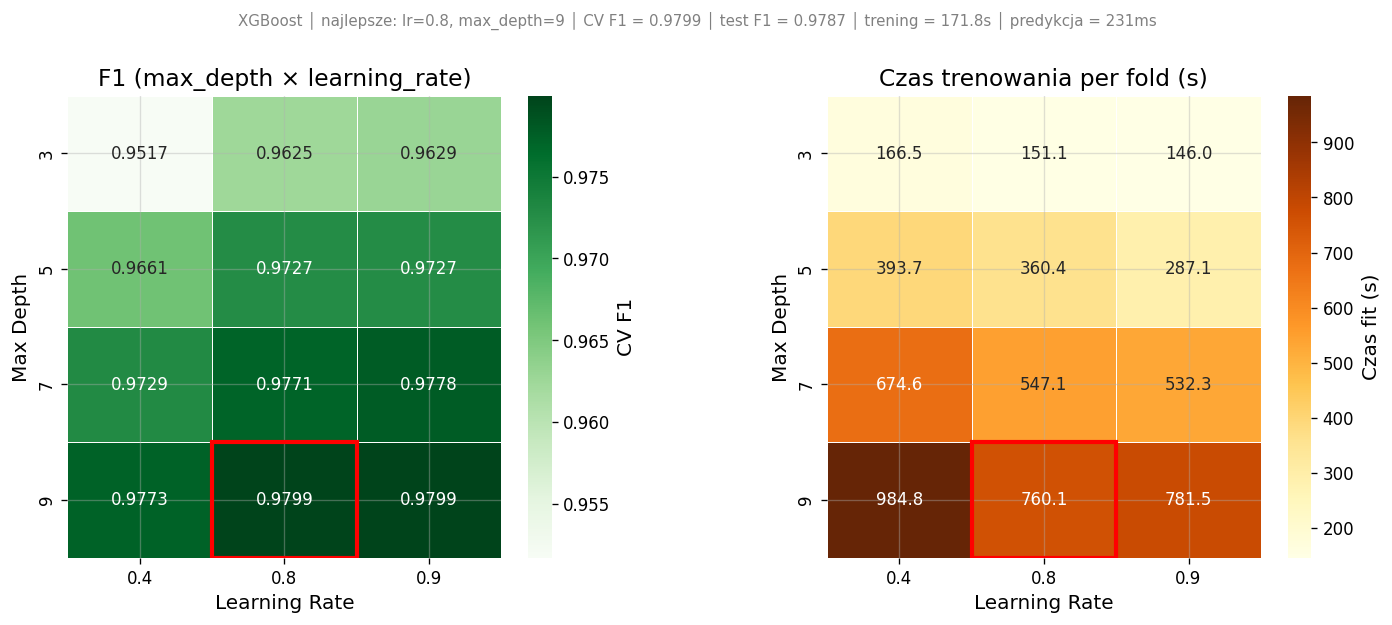

Wykres zapisany jako gridsearch_xgb.png


In [19]:
# ════════════════════════════════════════════════════════════
# XGBoost — strojenie learning_rate i max_depth (wersja odporna na pamięć)
# Trenuje po JEDNEJ kombinacji naraz, wyniki dopisuje do PKL.
# Można bezpiecznie zmieniać param_grid_xgb i wznawiać w dowolnym momencie.
# ════════════════════════════════════════════════════════════
import os, time, gc, itertools, joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

RESULTS_PKL  = 'xgb_results.pkl'
BEST_XGB_PKL = 'best_xgb.pkl'

param_grid_xgb = {
    'learning_rate': [0.4, 0.8, 0.9],
    'max_depth':     [3, 5, 7, 9],
    'n_estimators':  [100],
}

# ──────────────────────────────────────────────
# KLUCZOWE: upewnij się, że dane są SPARSE (nie dense).
# ──────────────────────────────────────────────
def ensure_sparse_float32(X):
    if sp.issparse(X):
        return X.astype(np.float32).tocsr()
    else:
        print("   UWAGA: dane wejściowe były DENSE — konwertuję do sparse (csr).")
        return sp.csr_matrix(X, dtype=np.float32)

X_train_tfidf = ensure_sparse_float32(X_train_tfidf)
X_test_tfidf  = ensure_sparse_float32(X_test_tfidf)

print(f"Kształt X_train: {X_train_tfidf.shape}, gęstość: "
      f"{X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4%}")

# ──────────────────────────────────────────────
# WCZYTAJ już policzone wyniki (jeśli plik istnieje) — to nasz "cache"
# Trzymamy listę wierszy (dict) w jednym pliku pkl.
# ──────────────────────────────────────────────
if os.path.exists(RESULTS_PKL):
    results_rows = joblib.load(RESULTS_PKL)
    n_before = len(results_rows)
    results_rows = [r for r in results_rows if not pd.isna(r['cv_f1_mean'])]
    # usuń duplikaty (zachowaj ostatni wpis dla danej kombinacji)
    dedup = {}
    for r in results_rows:
        key = (r['learning_rate'], r['max_depth'], r['n_estimators'])
        dedup[key] = r
    results_rows = list(dedup.values())
    n_dropped = n_before - len(results_rows)
    joblib.dump(results_rows, RESULTS_PKL)
    print(f"Wczytano {len(results_rows)} poprawnych wyników z {RESULTS_PKL}"
          + (f" (usunięto {n_dropped} nieudanych/pustych)" if n_dropped else ""))
else:
    results_rows = []

done_combos = set(
    (r['learning_rate'], r['max_depth'], r['n_estimators']) for r in results_rows
)

# ──────────────────────────────────────────────
# PĘTLA PO KOMBINACJACH — jedna naraz, zapis natychmiast po każdej
# ──────────────────────────────────────────────
combos = list(itertools.product(
    param_grid_xgb['learning_rate'],
    param_grid_xgb['max_depth'],
    param_grid_xgb['n_estimators'],
))

print(f"\nDo policzenia: {len(combos)} kombinacji "
      f"({len(combos) - sum(c in done_combos for c in combos)} nowych)\n")

for lr, depth, n_est in combos:
    if (lr, depth, n_est) in done_combos:
        print(f"[pomijam - już policzone] lr={lr}, depth={depth}, n_est={n_est}")
        continue

    print(f"Trenuję: lr={lr}, depth={depth}, n_est={n_est} ...", end=' ', flush=True)
    gc.collect()
    t0 = time.perf_counter()
    model = scores = None
    try:
        model = XGBClassifier(
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
            tree_method='hist',
            max_bin=128,
            learning_rate=lr,
            max_depth=depth,
            n_estimators=n_est,
            n_jobs=1,
        )
        scores = cross_val_score(
            model, X_train_tfidf, y_train,
            scoring='f1', cv=CV_FOLDS, n_jobs=1, error_score='raise'
        )
        fit_time = time.perf_counter() - t0
        row = {
            'learning_rate': lr, 'max_depth': depth, 'n_estimators': n_est,
            'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std(),
            'fit_time': fit_time,
        }
        print(f"F1={scores.mean():.4f} ({fit_time:.1f}s)")

    except Exception as e:
        fit_time = time.perf_counter() - t0
        row = {
            'learning_rate': lr, 'max_depth': depth, 'n_estimators': n_est,
            'cv_f1_mean': np.nan, 'cv_f1_std': np.nan, 'fit_time': fit_time,
        }
        print(f"BŁĄD: {type(e).__name__}: {e}")

    # dopisz wynik do listy i od razu zapisz cały cache do pkl
    results_rows.append(row)
    joblib.dump(results_rows, RESULTS_PKL)

    del model
    if scores is not None:
        del scores
    gc.collect()

print(f"\nWszystkie wyniki zapisane w {RESULTS_PKL}")

# ══════════════════════════════════════════════════════════════
# OD TEGO MIEJSCA: WSZYSTKO CZYTAMY Z PKL (nie z pamięci pętli)
# ══════════════════════════════════════════════════════════════
results_rows = joblib.load(RESULTS_PKL)
df_results = pd.DataFrame(results_rows).drop_duplicates(
    subset=['learning_rate', 'max_depth', 'n_estimators'], keep='last'
)

best_row_data = df_results.loc[df_results['cv_f1_mean'].idxmax()]
best_xgb_lr = best_row_data['learning_rate']
best_depth  = int(best_row_data['max_depth'])
best_n_est  = int(best_row_data['n_estimators'])

print("\n=== Najlepsza kombinacja (z pliku wyników) ===")
print(best_row_data)

# ──────────────────────────────────────────────
# FINALNY MODEL — z cache (.pkl), jeśli parametry się zgadzają;
# w przeciwnym razie trenujemy od nowa i zapisujemy.
# ──────────────────────────────────────────────
need_retrain = True

if os.path.exists(BEST_XGB_PKL):
    print(f"\nŁaduję zapisany finalny model XGBoost z {BEST_XGB_PKL}...")
    cached = joblib.load(BEST_XGB_PKL)
    best_xgb       = cached['model']
    final_fit_time = cached['fit_time']
    cached_params  = cached['params']

    if cached_params == {'learning_rate': best_xgb_lr, 'max_depth': best_depth, 'n_estimators': best_n_est}:
        print("   (parametry zgodne z najlepszą kombinacją — pomijam trening)")
        need_retrain = False
    else:
        print(f"   UWAGA: cache ma inne parametry ({cached_params}) niż aktualnie najlepsze "
              f"({{'learning_rate': {best_xgb_lr}, 'max_depth': {best_depth}, 'n_estimators': {best_n_est}}}) "
              f"— trenuję od nowa.")

if need_retrain:
    print("\nTrenuję finalny model XGBoost...")
    best_xgb = XGBClassifier(
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0,
        tree_method='hist', max_bin=128, n_jobs=1,
        learning_rate=best_xgb_lr, max_depth=best_depth, n_estimators=best_n_est,
    )
    t0 = time.perf_counter()
    best_xgb.fit(X_train_tfidf, y_train)
    final_fit_time = time.perf_counter() - t0

    joblib.dump({
        'model': best_xgb,
        'fit_time': final_fit_time,
        'params': {'learning_rate': best_xgb_lr, 'max_depth': best_depth, 'n_estimators': best_n_est},
    }, BEST_XGB_PKL)
    print(f"Model zapisany: {BEST_XGB_PKL}")

t0 = time.perf_counter()
y_xgb = best_xgb.predict(X_test_tfidf)
pred_time = time.perf_counter() - t0

f1_test = f1_score(y_test, y_xgb)

print(f"\nF1 (test):       {f1_test:.4f}")
print(f"Czas trenowania:  {final_fit_time:.2f}s")
print(f"Czas predykcji:   {pred_time*1000:.1f}ms")

# ──────────────────────────────────────────────
# WYKRES — z danych wczytanych z PKL
# ──────────────────────────────────────────────
df_plot = df_results[df_results['n_estimators'] == best_n_est].copy()

pivot_f1 = df_plot.pivot_table(
    index='max_depth', columns='learning_rate', values='cv_f1_mean', dropna=False
)
pivot_time = df_plot.pivot_table(
    index='max_depth', columns='learning_rate', values='fit_time', dropna=False
)

best_row = list(pivot_f1.index).index(best_depth)
best_col = list(pivot_f1.columns).index(best_xgb_lr)

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='Greens',
            ax=ax1, linewidths=0.5, cbar_kws={'label': 'CV F1'})
ax1.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax1.set_title('F1 (max_depth × learning_rate)')
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Max Depth')

sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='YlOrBr',
            ax=ax2, linewidths=0.5, cbar_kws={'label': 'Czas fit (s)'})
ax2.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
              fill=False, edgecolor='red', lw=2.5, zorder=5))
ax2.set_title('Czas trenowania per fold (s)')
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Max Depth')

fig.suptitle(
    f"XGBoost │ najlepsze: lr={best_xgb_lr}, max_depth={best_depth} │ "
    f"CV F1 = {best_row_data['cv_f1_mean']:.4f} │ test F1 = {f1_test:.4f} │ "
    f"trening = {final_fit_time:.1f}s │ predykcja = {pred_time*1000:.0f}ms",
    fontsize=9, color='gray', y=1.02,
)

plt.savefig('gridsearch_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako gridsearch_xgb.png")

Osobiście wyb rałbym depth 5 i learnin rate 0.4 bo wynik jest lekko gorszy ale czas jest tylko 15.8 s zamioast 46s

## 7. Krzywe uczenia (Learning Curves)

Krzywe uczenia pokazują, jak zmienia się skuteczność modelu wraz ze wzrostem liczby próbek treningowych — pomagają zidentyfikować **przeuczenie (overfitting)** i **niedouczenie (underfitting)**.


Ładuję zapisane krzywe uczenia...
  ✓ Naive Bayes — z pliku
  ✓ Logistic Regression — z pliku
  ✓ SVM — z pliku
  ✓ Random Forest — z pliku
  ✓ XGBoost — z pliku


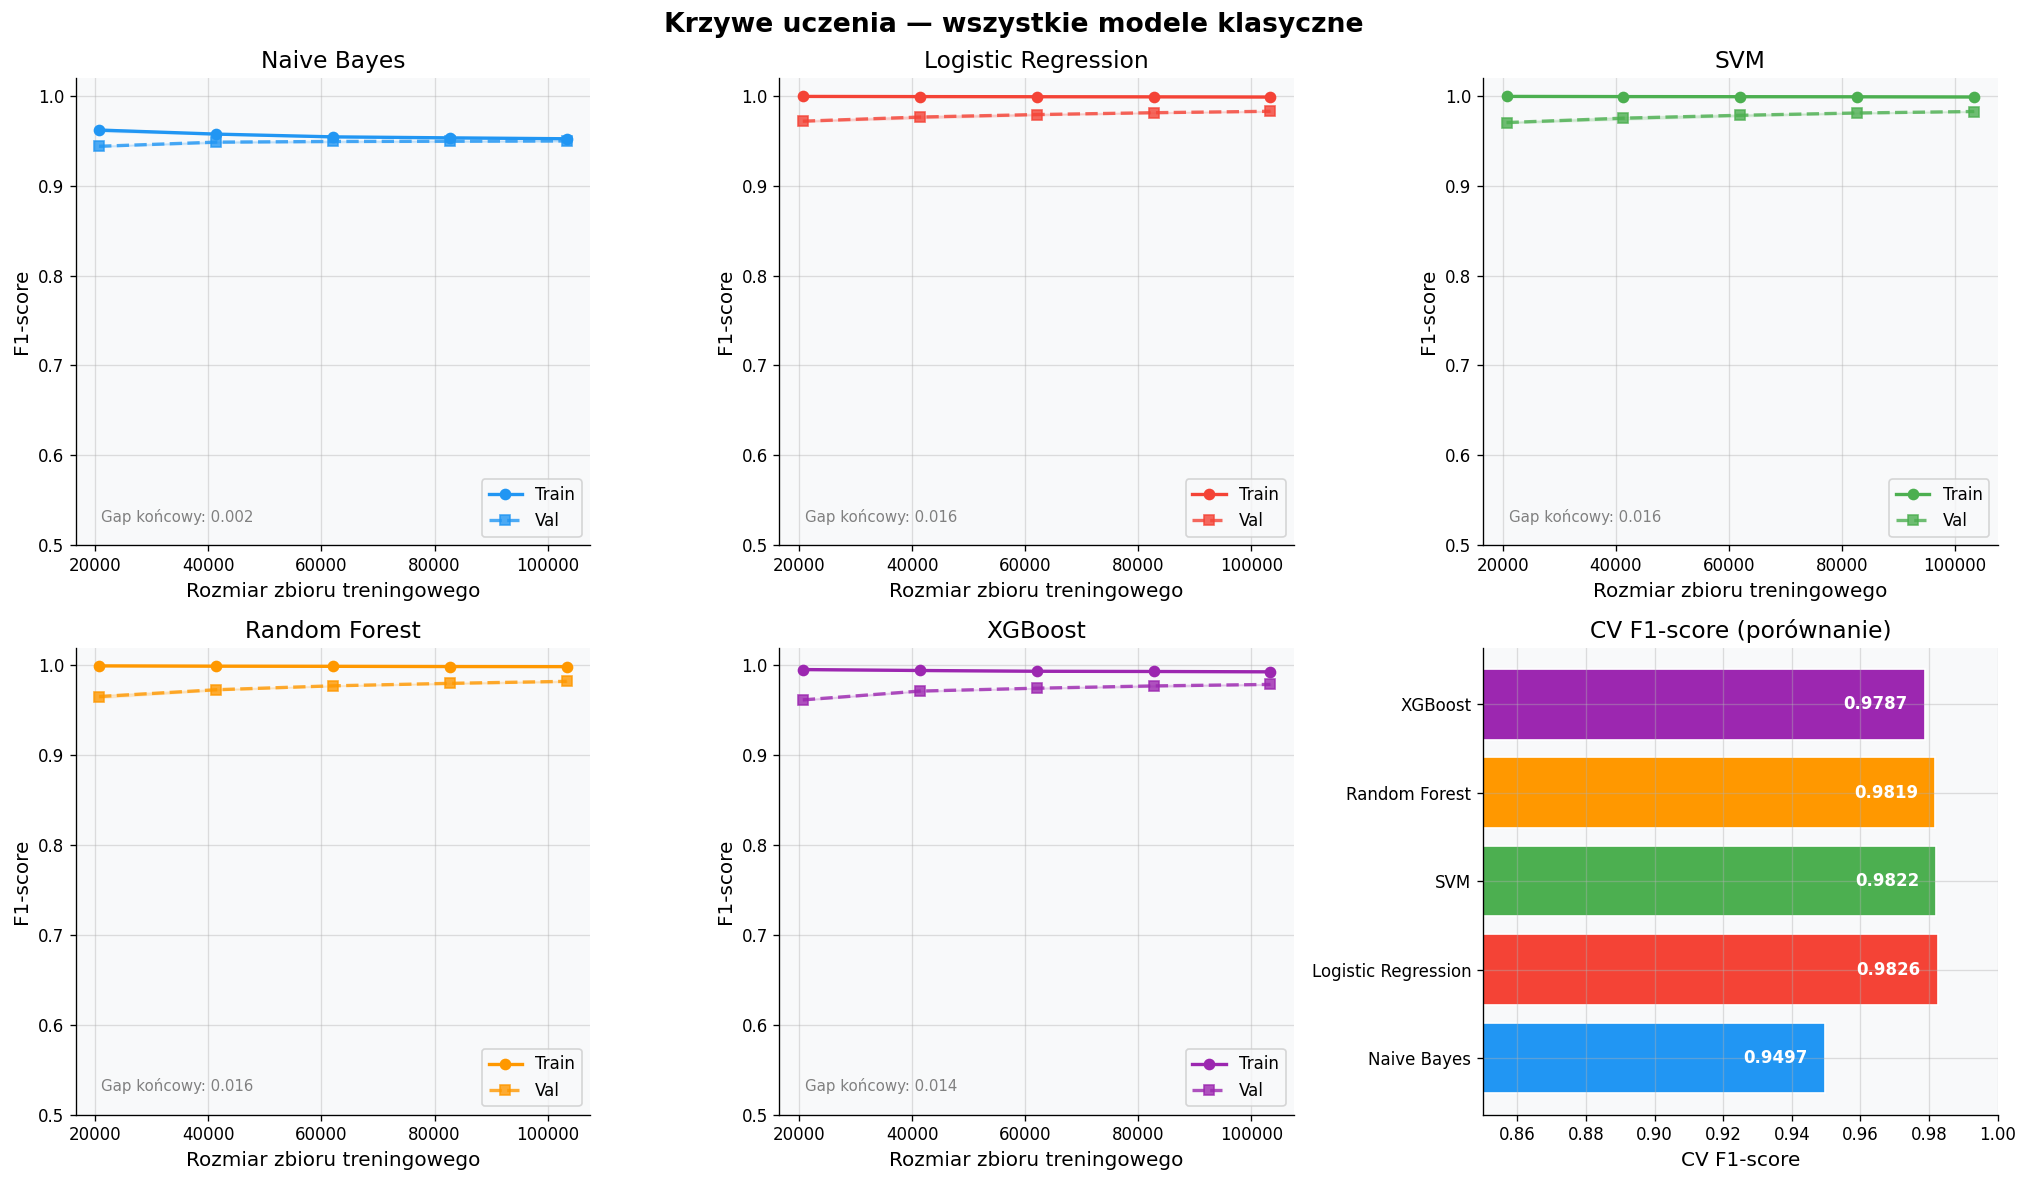

Zapisano: learning_curves.png
Krzywe uczenia: learning_curves.csv (5/5 modeli)
Podsumowanie CV: learning_curves_cv_summary.csv


In [20]:
LC_CURVES_FILE = 'learning_curves.csv'
LC_SUMMARY_FILE = 'learning_curves_cv_summary.csv'

# Pełny zbiór treningowy — bez podpróbkowania (limit LC_MAX_SAMPLES wywalony)
X_lc, y_lc = X_train, y_train

X_lc_tfidf = tfidf.transform(X_lc)

from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.base import clone


def _draw_learning_curve(ax, title, color, train_sizes, train_mean, train_std, val_mean, val_std):
    ax.plot(train_sizes, train_mean, 'o-', color=color, label='Train', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.plot(train_sizes, val_mean, 's--', color=color, label='Val', linewidth=2, alpha=0.8)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel('Rozmiar zbioru treningowego')
    ax.set_ylabel('F1-score')
    ax.legend(loc='lower right')
    ax.set_ylim(0.5, 1.02)
    gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.05, f'Gap końcowy: {gap:.3f}', transform=ax.transAxes,
            fontsize=9, color='gray')
    return gap


def compute_learning_curve_row(estimator, title, X, y, color, ax, cv=LC_CV_FOLDS,
                                scoring='f1', n_jobs=-1):
    if not hasattr(estimator, 'fit'):
        raise TypeError(
            f'{title}: estimator musi mieć fit(), dostałem {type(estimator).__name__}={estimator!r}. '
            f'Uruchom ponownie komórkę Logistic Regression (best_lr bywa nadpisywany przez learning_rate XGBoost).'
        )
    train_sizes_grid = np.linspace(0.2, 1.0, LC_TRAIN_SIZES)
    train_sizes, train_scores, test_scores = sk_learning_curve(
        estimator=clone(estimator),
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        train_sizes=train_sizes_grid,
        n_jobs=n_jobs,
        error_score='raise',  # <- nie chowaj błędów jako NaN, pokaż prawdziwy traceback
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = test_scores.mean(axis=1)
    val_std    = test_scores.std(axis=1)
    gap = _draw_learning_curve(ax, title, color, train_sizes, train_mean, train_std, val_mean, val_std)
    return pd.DataFrame({
        'model': title,
        'train_size': train_sizes,
        'train_mean': train_mean,
        'train_std': train_std,
        'val_mean': val_mean,
        'val_std': val_std,
        'gap_koncowy': gap,
    })

def plot_learning_curve_from_saved(df_model, title, color, ax):
    _draw_learning_curve(
        ax, title, color,
        df_model['train_size'].values,
        df_model['train_mean'].values,
        df_model['train_std'].values,
        df_model['val_mean'].values,
        df_model['val_std'].values,
    )

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Krzywe uczenia — wszystkie modele klasyczne', fontsize=16, fontweight='bold')

# best_lr bywa nadpisywany floatem (np. learning_rate=0.8 z XGBoost) — bierzemy estymatory z GridSearch / finalnego modelu
def _as_estimator(obj, fallback):
    return obj if hasattr(obj, 'fit') else fallback

# Przywróć best_lr w namespace (kolejne komórki też na tym polegają)
if not hasattr(best_lr, 'fit'):
    best_lr = gs_lr.best_estimator_
    print('Uwaga: best_lr był floatem — przywrócono gs_lr.best_estimator_')

# XGBoost: wymuś n_jobs=1 na estymatorze, żeby uniknąć oversubscription wątków
# (learning_curve i tak odpala foldy równolegle przez n_jobs; jeśli model XGBoost
# też próbuje być wielowątkowy, procesy potrafią się wywrócić po cichu -> NaN)
xgb_for_lc = clone(best_xgb).set_params(n_jobs=1)

models_lc = [
    (_as_estimator(best_nb,  gs_nb.best_estimator_),  'Naive Bayes',         PALETTE[0], -1),
    (_as_estimator(best_lr,  gs_lr.best_estimator_),  'Logistic Regression', PALETTE[1], -1),
    (_as_estimator(best_svm, gs_svm.best_estimator_), 'SVM',                 PALETTE[2], -1),
    (_as_estimator(best_rf,  gs_rf.best_estimator_),  'Random Forest',       PALETTE[3], -1),
    (xgb_for_lc, 'XGBoost', PALETTE[4], 1),  # <- n_jobs=1 tylko dla XGBoost
]


loaded_from_cache = os.path.exists(LC_CURVES_FILE)
if loaded_from_cache:
    print("Ładuję zapisane krzywe uczenia...")
    df_learning_curves = pd.read_csv(LC_CURVES_FILE)

    # Usuń niekompletne/zepsute wpisy XGBoosta (np. z NaN po cichym błędzie)
    # -- inaczej cache uzna model za "gotowy" mimo brakujących wartości.
    xgb_rows = df_learning_curves[df_learning_curves['model'] == 'XGBoost']
    xgb_broken = xgb_rows['train_mean'].isna().any() or len(xgb_rows) < LC_TRAIN_SIZES
    if xgb_broken and len(xgb_rows) > 0:
        print(f"  UWAGA: znaleziono niepełne/zepsute dane XGBoost w {LC_CURVES_FILE} "
              f"({xgb_rows['train_mean'].isna().sum()} NaN / {len(xgb_rows)} wierszy) — usuwam, przeliczę od nowa.")
        df_learning_curves = df_learning_curves[df_learning_curves['model'] != 'XGBoost']
        df_learning_curves.to_csv(LC_CURVES_FILE, index=False)

    done_models = set(df_learning_curves['model'].unique())
else:
    print("Obliczam krzywe uczenia (może potrwać kilka minut)...")
    df_learning_curves = pd.DataFrame()
    done_models = set()

new_rows = []
for ax, (est, title, color, n_jobs) in zip(axes.ravel(), models_lc):
    if title in done_models:
        print(f"  ✓ {title} — z pliku")
        plot_learning_curve_from_saved(
            df_learning_curves[df_learning_curves['model'] == title], title, color, ax
        )
    else:
        print(f"  {title} — obliczam (n_jobs={n_jobs})...")
        row = compute_learning_curve_row(est, title, X_lc_tfidf, y_lc, color, ax, n_jobs=n_jobs)
        new_rows.append(row)
        row.to_csv(
            LC_CURVES_FILE,
            mode='a',
            header=not os.path.exists(LC_CURVES_FILE),
            index=False,
        )
        done_models.add(title)

if new_rows:
    df_learning_curves = pd.concat([df_learning_curves, *new_rows], ignore_index=True)

# Podobnie: jeśli summary ma NaN dla XGBoosta (albo brakuje modelu), przelicz od nowa
recompute_summary = True
if os.path.exists(LC_SUMMARY_FILE):
    df_cv_summary = pd.read_csv(LC_SUMMARY_FILE)
    if df_cv_summary['cv_f1'].isna().any() or set(df_cv_summary['model']) != {t for _, t, _, _ in models_lc}:
        print(f"  UWAGA: {LC_SUMMARY_FILE} ma braki — przeliczam summary od nowa.")
    else:
        names_lc = df_cv_summary['model'].tolist()
        val_scores = df_cv_summary['cv_f1'].tolist()
        recompute_summary = False

if recompute_summary:
    print("  CV F1-score — obliczam...")
    names_lc = [t for _, t, _, _ in models_lc]
    val_scores = [
        cross_val_score(m, X_lc_tfidf, y_lc, cv=LC_CV_FOLDS, scoring='f1',
                         n_jobs=n_jobs, error_score='raise').mean()
        for m, _, _, n_jobs in models_lc
    ]
    pd.DataFrame({'model': names_lc, 'cv_f1': val_scores}).to_csv(LC_SUMMARY_FILE, index=False)
    print(f"  Zapisano {LC_SUMMARY_FILE}")

colors_lc = [c for _, _, c, _ in models_lc]
# Ostatni subplot: porównanie końcowych wyników
ax = axes[1, 2]
bars = ax.barh(names_lc, val_scores, color=colors_lc, edgecolor='white')
for bar, val in zip(bars, val_scores):
    ax.text(val - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', fontweight='bold', fontsize=10, color='white')
ax.set_xlim(0.85, 1.0)
ax.set_xlabel('CV F1-score')
ax.set_title('CV F1-score (porównanie)')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: learning_curves.png")
if os.path.exists(LC_CURVES_FILE):
    print(f"Krzywe uczenia: {LC_CURVES_FILE} ({len(done_models)}/5 modeli)")
if os.path.exists(LC_SUMMARY_FILE):
    print(f"Podsumowanie CV: {LC_SUMMARY_FILE}")

## 8. Analiza ważności cech TF-IDF

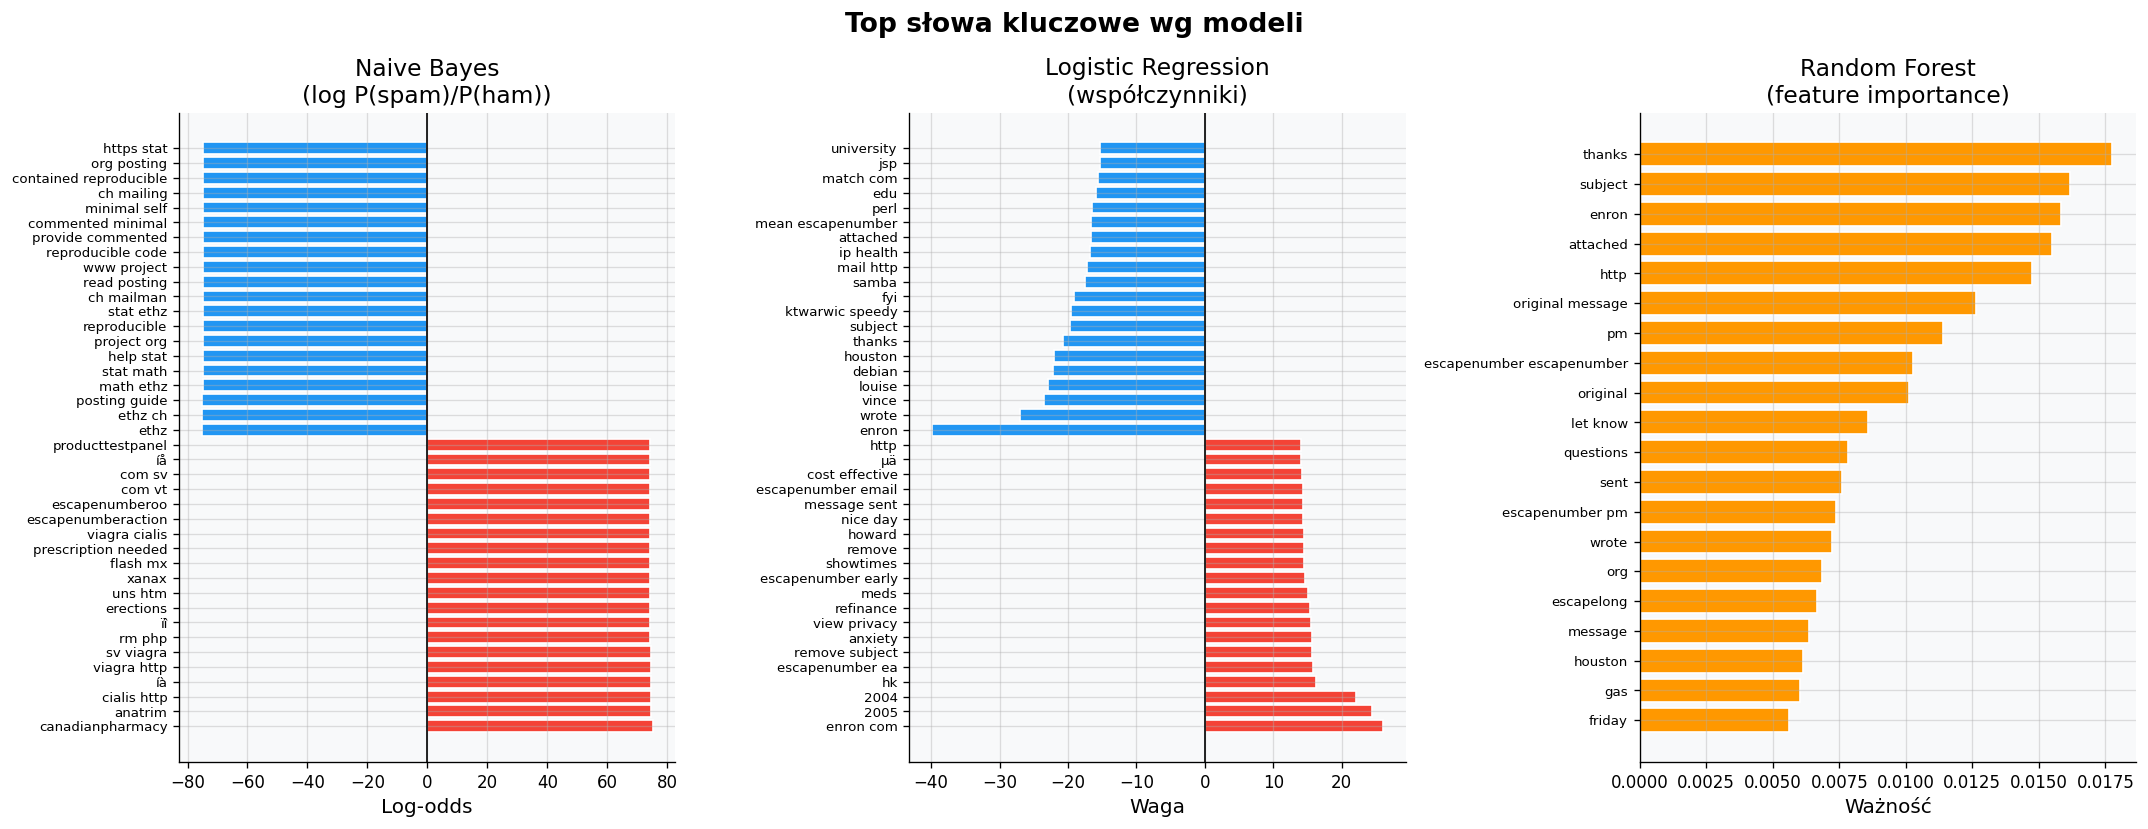

Zapisano: feature_importance.png


In [21]:
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top słowa kluczowe wg modeli', fontsize=16, fontweight='bold')

# --- Naive Bayes: log-prawdopodobieństwa ---
ax = axes[0]
log_prob_diff = best_nb.feature_log_prob_[1] - best_nb.feature_log_prob_[0]
top_k = 20
top_idx = np.argsort(log_prob_diff)[-top_k:][::-1]
bot_idx = np.argsort(log_prob_diff)[:top_k]

combined_idx = np.concatenate([top_idx, bot_idx])
combined_vals = log_prob_diff[combined_idx]
combined_names = feature_names[combined_idx]
colors_feat = [PALETTE[1] if v > 0 else PALETTE[0] for v in combined_vals]
y_pos = range(len(combined_idx))
ax.barh(y_pos, combined_vals, color=colors_feat, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(combined_names, fontsize=8)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Naive Bayes\n(log P(spam)/P(ham))')
ax.set_xlabel('Log-odds')

# --- Logistic Regression: wagi ---
ax = axes[1]
coef = best_lr.coef_[0]
top_lr = np.argsort(coef)[-top_k:][::-1]
bot_lr = np.argsort(coef)[:top_k]
idx_lr = np.concatenate([top_lr, bot_lr])
vals_lr = coef[idx_lr]
colors_lr = [PALETTE[1] if v > 0 else PALETTE[0] for v in vals_lr]
y_pos = range(len(idx_lr))
ax.barh(y_pos, vals_lr, color=colors_lr, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names[idx_lr], fontsize=8)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression\n(współczynniki)')
ax.set_xlabel('Waga')

# --- Random Forest: feature importance ---
ax = axes[2]
importances = best_rf.feature_importances_
top_rf = np.argsort(importances)[-top_k:][::-1]
ax.barh(range(top_k), importances[top_rf][::-1],
        color=PALETTE[3], edgecolor='white')
ax.set_yticks(range(top_k))
ax.set_yticklabels(feature_names[top_rf][::-1], fontsize=8)
ax.set_title('Random Forest\n(feature importance)')
ax.set_xlabel('Ważność')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: feature_importance.png")


## 9. Macierze konfuzji — modele klasyczne

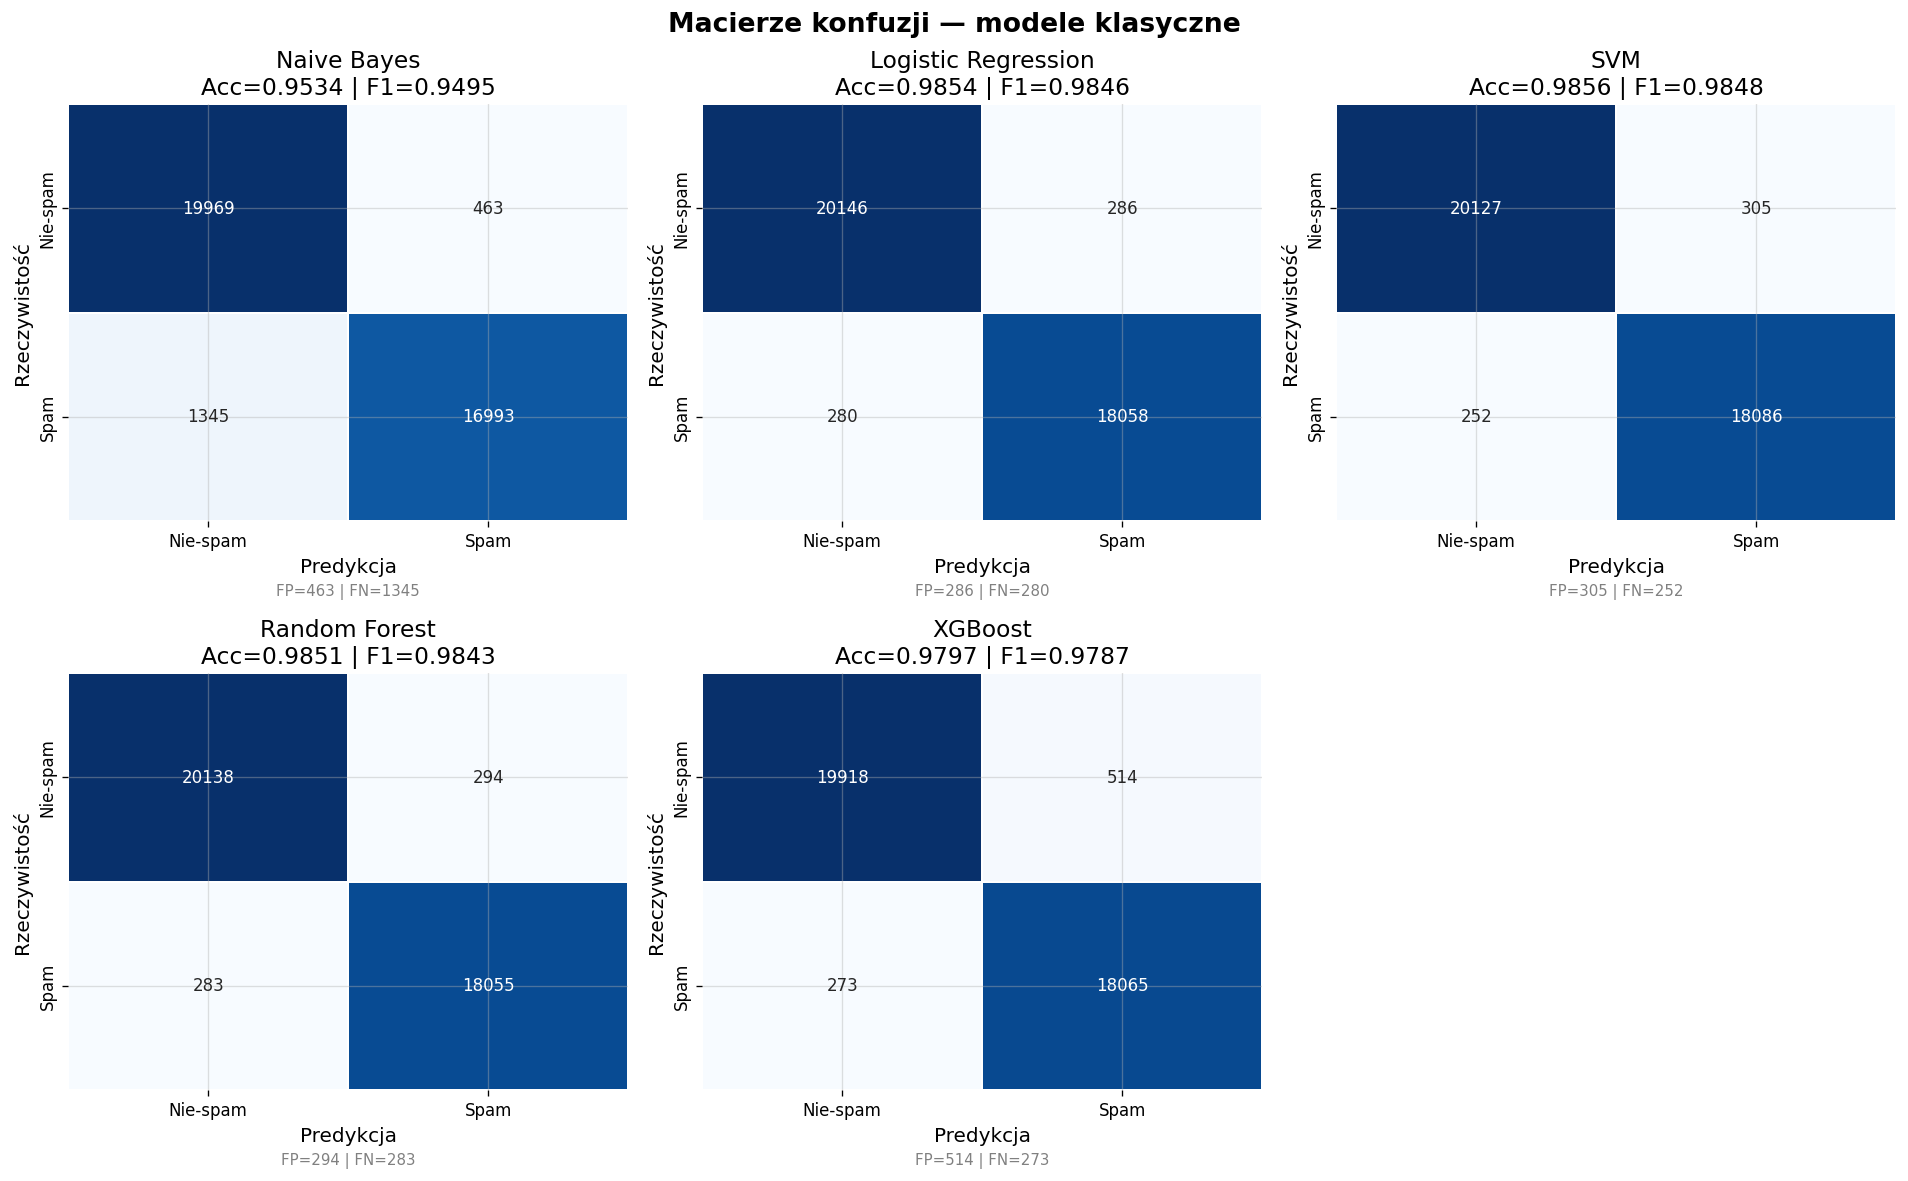

Zapisano: confusion_matrices.png


In [22]:
model_preds = {
    'Naive Bayes':         y_nb,
    'Logistic Regression': y_lr,
    'SVM':                 y_svm,
    'Random Forest':       y_rf,
    'XGBoost':             y_xgb,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Macierze konfuzji — modele klasyczne', fontsize=16, fontweight='bold')

for ax, (name, preds), color in zip(axes.ravel(), model_preds.items(), PALETTE):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Nie-spam', 'Spam'],
                yticklabels=['Nie-spam', 'Spam'],
                linewidths=1, linecolor='white', cbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, preds):.4f} | F1={f1_score(y_test, preds):.4f}')
    ax.set_xlabel('Predykcja')
    ax.set_ylabel('Rzeczywistość')
    ax.text(0.5, -0.18, f'FP={fp} | FN={fn}', transform=ax.transAxes,
            ha='center', fontsize=9, color='gray')

# Ukryj ostatni subplot
axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: confusion_matrices.png")


## 10. Model BERT

Najpierw sprawdzamy, czy pre-trained BERT poprawnie się wczytuje i jak tokenizuje e-maile. Dopiero potem przeprowadzamy fine-tuning do klasyfikacji spam/ham.


In [24]:
# --- Opcjonalny podzbiór danych (przyspiesza eksperymenty) ---
if 'SUBSET_SIZE' in globals() and SUBSET_SIZE is not None and len(data) > SUBSET_SIZE:
    data_subset = data.sample(n=SUBSET_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Używam podzbioru danych: {len(data_subset):,} rekordów (SUBSET_SIZE={SUBSET_SIZE})")
else:
    data_subset = data

X = data_subset['text']
y = data_subset['label'].apply(lambda x: 1 if x == 'Spam' else 0)

print(f"\nRekordy po próbkowaniu: {len(data_subset):,}")
print(f"Ham:  {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"Spam: {y.sum():,} ({y.mean()*100:.1f}%)")

Używam podzbioru danych: 5,000 rekordów (SUBSET_SIZE=5000)

Rekordy po próbkowaniu: 5,000
Ham:  2,680 (53.6%)
Spam: 2,320 (46.4%)


In [25]:
X_train_BERT, X_test_BERT, y_train_BERT, y_test_BERT = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Zbiór treningowy BERT: {len(X_train_BERT):,} ({len(X_train_BERT)/len(X)*100:.1f}%)")
print(f"Zbiór testowy BERT:    {len(X_test_BERT):,}  ({len(X_test_BERT)/len(X)*100:.1f}%)")
print(f"\nSpam w train BERT: {y_train_BERT.mean()*100:.1f}%")
print(f"Spam w test BERT:  {y_test_BERT.mean()*100:.1f}%")

# Pełna pula danych dla BERT (do wariantów >1x) — z PEŁNEGO, nieokrojonego zbioru
X_clean = data_clean['text']
y_clean = data_clean['label'].apply(lambda x: 1 if x == 'Spam' else 0)
_idx_tr, _idx_te = train_test_split(
    np.arange(len(X_clean)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clean,
)
X_train_full_BERT = X_clean.iloc[_idx_tr].reset_index(drop=True)
y_train_full_BERT = y_clean.iloc[_idx_tr].reset_index(drop=True)
print(f"\nFull BERT: {len(X_train_full_BERT):,}")


Zbiór treningowy BERT: 4,000 (80.0%)
Zbiór testowy BERT:    1,000  (20.0%)

Spam w train BERT: 46.4%
Spam w test BERT:  46.4%

Full BERT: 155,079


### Sprawdzenie modelu pre-trained

Wczytujemy `bert-base-uncased` z Hugging Face, tokenizujemy przykładowe wiadomości z zbioru i uruchamiamy forward pass. Głowa klasyfikacji jest jeszcze niewytrenowana — predykcje są losowe do momentu fine-tuningu.


In [26]:
import os
import torch
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification

os.environ["HF_HOME"] = "./cache"

print(f"Model:      {BERT_MODEL}")
print(f"Urządzenie: {device}")

tokenizer_check = BertTokenizer.from_pretrained(BERT_MODEL)
model_check = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
model_check.to(device)
model_check.eval()

n_params = sum(p.numel() for p in model_check.parameters())
print(f"Parametry:  {n_params:,}")
print("\nModel i tokenizer wczytane poprawnie\n")

ham_pos  = int(np.where(y_train_BERT.values == 0)[0][0])
spam_pos = int(np.where(y_train_BERT.values == 1)[0][0])
examples = [
    ("Nie-spam (ham)",  str(X_train_BERT.iloc[ham_pos])),
    ("Spam",            str(X_train_BERT.iloc[spam_pos])),
]

def bert_preview(label_name, text):
    enc = tokenizer_check(text, return_tensors="pt", truncation=True, max_length=128)
    tokens = tokenizer_check.convert_ids_to_tokens(enc["input_ids"][0])
    snippet = text[:120] + ("..." if len(text) > 120 else "")
    print(f"--- {label_name} ---")
    print(f"Tekst: {snippet}")
    tok_preview = " ".join(tokens[:18]) + ("..." if len(tokens) > 18 else "")
    print(f"Tokeny ({len(tokens)}): {tok_preview}")
    with torch.no_grad():
        out = model_check(**{k: v.to(device) for k, v in enc.items()})
    probs = F.softmax(out.logits, dim=-1)[0].cpu().numpy()
    pred = int(probs.argmax())
    pred_name = "Spam" if pred == 1 else "Nie-spam"
    logit_ham = out.logits[0, 0].item()
    logit_spam = out.logits[0, 1].item()
    print(f"Logity: nie-spam={logit_ham:.3f}, spam={logit_spam:.3f}")
    print(f"Predykcja (niewytrenowana głowa): {pred_name} ({probs[pred] * 100:.1f}%)\n")

for label_name, text in examples:
    bert_preview(label_name, text)

print("ℹGłowa klasyfikacji jest losowa — dopiero fine-tuning uczy rozróżniania spam/ham.")


Model:      bert-base-uncased
Urządzenie: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametry:  109,483,778

Model i tokenizer wczytane poprawnie

--- Nie-spam (ham) ---
Tekst: this is a very rough agenda if you have any updates please let me know a s a p thanks sue sue ford enron corp tel escape...
Tokeny (54): [CLS] this is a very rough agenda if you have any updates please let me know a s...
Logity: nie-spam=-0.290, spam=-0.546
Predykcja (niewytrenowana głowa): Nie-spam (56.4%)

--- Spam ---
Tekst: the bull report campaign for asvpprice escapenumber escapenumber escapenumber day target price escapenumbermarket hellis...
Tokeny (46): [CLS] the bull report campaign for as ##v ##pp ##rice escape ##num ##ber escape ##num ##ber escape ##num...
Logity: nie-spam=-0.224, spam=-0.663
Predykcja (niewytrenowana głowa): Nie-spam (60.8%)

ℹGłowa klasyfikacji jest losowa — dopiero fine-tuning uczy rozróżniania spam/ham.


### Fine-tuning


In [27]:
from pathlib import Path

tokenizer_bert = BertTokenizer.from_pretrained(BERT_MODEL)

def tokenize_bert(texts):
    return tokenizer_bert(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

train_encodings = tokenize_bert(X_train_BERT)
test_encodings  = tokenize_bert(X_test_BERT)

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels.values

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset_BERT = EmailDataset(train_encodings, y_train_BERT)
test_dataset_BERT  = EmailDataset(test_encodings,  y_test_BERT)

def make_email_dataset(X_part, y_part):
    return EmailDataset(tokenize_bert(X_part), y_part)

def get_bert_train_subset(multiplier):
    """Zwraca podzbiór treningowy dla BERT (0.5x–8.0x względem len(X_train_BERT))."""
    base_n = len(X_train_BERT)
    target_n = int(base_n * multiplier)

    if multiplier <= 1.0:
        pool_X, pool_y = X_train_BERT, y_train_BERT
    else:
        pool_X, pool_y = X_train_full_BERT, y_train_full_BERT

    target_n = min(target_n, len(pool_X))
    target_n = max(target_n, 10)

    if target_n >= len(pool_X):
        return pool_X.reset_index(drop=True), pool_y.reset_index(drop=True)

    idx, _ = train_test_split(
        np.arange(len(pool_X)),
        train_size=target_n,
        stratify=pool_y,
        random_state=RANDOM_STATE,
    )
    return pool_X.iloc[idx].reset_index(drop=True), pool_y.iloc[idx].reset_index(drop=True)

print("Datasety BERT gotowe")


Datasety BERT gotowe


In [29]:
from pathlib import Path
import os
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

os.environ["HF_HOME"] = "./cache"

MODEL_DIR = Path("results/bert_finetuned")

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    report_to="none",
)

def build_trainer(model, train_ds, eval_ds=test_dataset_BERT):
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
    )


### Wpływ liczności danych treningowych na fine-tuning BERT

Trenujemy BERT na **0.5×**, **1.0×**, **2.0×**, **4.0×** i **8.0×** liczby przykładów względem bazowego `X_train_BERT` (ten sam zbiór testowy). Dla mnożników **> 1.0×** używamy rozszerzonego puli `X_train_full_BERT` z pełnego oczyszczonego zbioru. Już wytrenowane warianty są wczytywane z cache — trenowane są tylko brakujące.


BERT fine-tuning — 0.5x (2,000 próbek treningowych)
Brak cache — trenuję od zera...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.459480,0.199658
2,0.170421,0.151964
3,0.076534,0.153005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Czas treningu/ładowania: 7672.7s | Czas predykcji: 59.3s | Łącznie: 7732.0s

BERT fine-tuning — 4.0x (16,000 próbek treningowych)
Ładuję zapisany model — pomijam trening: results\bert_finetuned_4p0x


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Czas treningu/ładowania: 1.0s | Czas predykcji: 62.3s | Łącznie: 63.3s

BERT fine-tuning — 8.0x (32,000 próbek treningowych)
Ładuję zapisany model — pomijam trening: results\bert_finetuned_8p0x


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Czas treningu/ładowania: 0.7s | Czas predykcji: 65.7s | Łącznie: 66.4s

=== BERT — wpływ liczby przykładów treningowych ===
         N_train  Accuracy  Precision  Recall  F1-score  Czas treningu (s)  Czas predykcji (s)  Czas łączny (s)
Mnożnik                                                                                                        
0.5x        2000     0.952     0.9483  0.9483    0.9483          2324.3842             77.7830        2402.1692
1.0x        4000     0.962     0.9754  0.9418    0.9583          4454.5323             82.5833        4537.1166
2.0x        8000     0.971     0.9801  0.9569    0.9684          7672.7313             59.2664        7731.9978
4.0x       16000     0.974     0.9740  0.9698    0.9719             1.0338             62.2910          63.3248
8.0x       32000     0.983     0.9934  0.9698    0.9815             0.7278             65.6782          66.4060


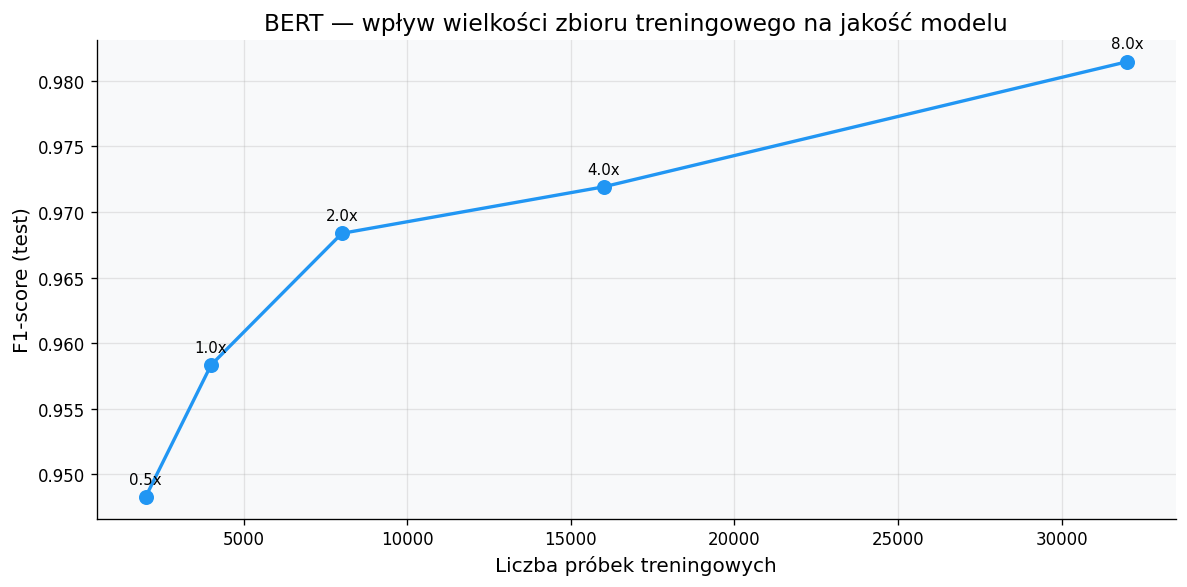

Zapisano: bert_train_size_comparison.png


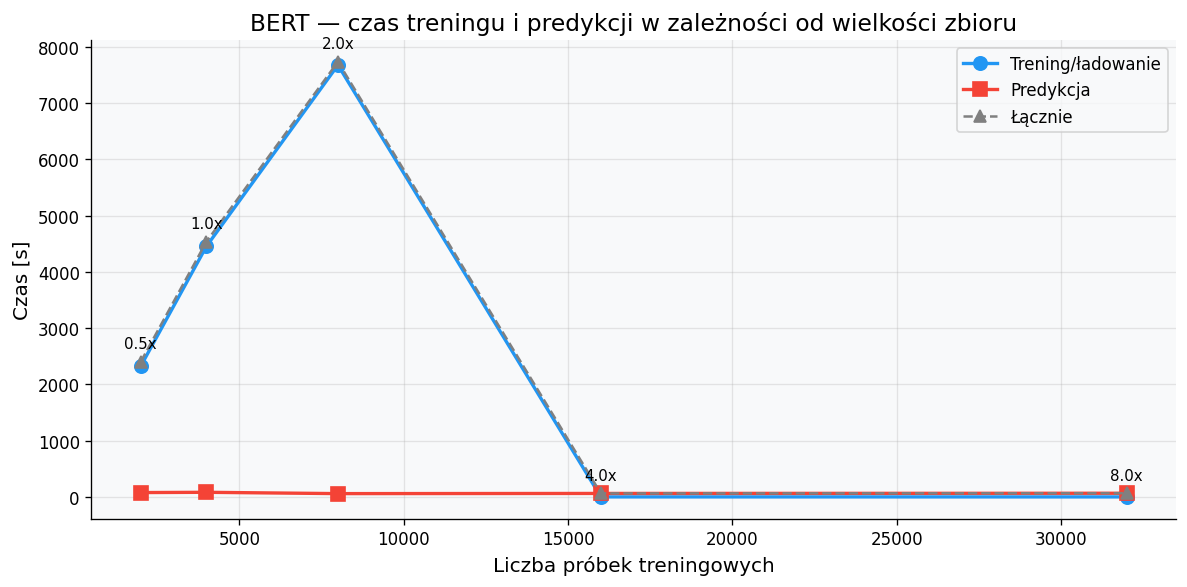

Zapisano: bert_train_time_comparison.png


In [30]:
import time

bert_size_rows = []

for mult in BERT_TRAIN_SIZE_MULTIPLIERS:
    label = f"{mult:.1f}x"
    model_dir = MODEL_DIR if mult == 1.0 else Path(f"results/bert_finetuned_{label.replace('.', 'p')}")

    X_sub, y_sub = get_bert_train_subset(mult)
    train_ds = make_email_dataset(X_sub, y_sub)
    n_train = len(train_ds)
    target_n = int(len(X_train_BERT) * mult)

    print(f"\n{'='*60}")
    print(f"BERT fine-tuning — {label} ({n_train:,} próbek treningowych)")
    if n_train < target_n:
        print(f"ℹCel: {target_n:,} — ograniczono pulą X_train_full_BERT ({len(X_train_full_BERT):,})")
    print(f"{'='*60}")

    t_start = time.time()

    if mult == 1.0 and model_dir.exists() and 'model' in globals() and 'trainer' in globals():
        print("Używam bazowego modelu (1.0x) z poprzedniej komórki")
        model_run = model
        trainer_run = trainer
        train_time = 0.0
    elif model_dir.exists():
        print(f"Ładuję zapisany model — pomijam trening: {model_dir}")
        model_run = BertForSequenceClassification.from_pretrained(model_dir)
        trainer_run = build_trainer(model_run, train_ds)
        train_time = time.time() - t_start
    else:
        print("Brak cache — trenuję od zera...")
        model_run = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
        trainer_run = build_trainer(model_run, train_ds)
        trainer_run.train()
        model_dir.mkdir(parents=True, exist_ok=True)
        trainer_run.save_model(model_dir)
        print(f"Zapisano: {model_dir}")
        train_time = time.time() - t_start

    t_pred_start = time.time()
    pred_run = trainer_run.predict(test_dataset_BERT)
    pred_time = time.time() - t_pred_start

    total_time = time.time() - t_start
    y_pred_run = np.argmax(pred_run.predictions, axis=1)

    print(f"Czas treningu/ładowania: {train_time:.1f}s | Czas predykcji: {pred_time:.1f}s | Łącznie: {total_time:.1f}s")

    bert_size_rows.append({
        'Mnożnik': label,
        'N_train': n_train,
        'Accuracy': accuracy_score(y_test_BERT, y_pred_run),
        'Precision': precision_score(y_test_BERT, y_pred_run),
        'Recall': recall_score(y_test_BERT, y_pred_run),
        'F1-score': f1_score(y_test_BERT, y_pred_run),
        'Czas treningu (s)': train_time,
        'Czas predykcji (s)': pred_time,
        'Czas łączny (s)': total_time,
    })

bert_size_df = pd.DataFrame(bert_size_rows).set_index('Mnożnik')
print("\n=== BERT — wpływ liczby przykładów treningowych ===")
print(bert_size_df.round(4).to_string())

# --- Wykres jakości (F1) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bert_size_df['N_train'], bert_size_df['F1-score'], 'o-', color=PALETTE[0], linewidth=2, markersize=8)
for x, y, lbl in zip(bert_size_df['N_train'], bert_size_df['F1-score'], bert_size_df.index):
    ax.annotate(lbl, (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('Liczba próbek treningowych')
ax.set_ylabel('F1-score (test)')
ax.set_title('BERT — wpływ wielkości zbioru treningowego na jakość modelu')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_train_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: bert_train_size_comparison.png")

# --- Wykres czasu ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bert_size_df['N_train'], bert_size_df['Czas treningu (s)'], 'o-',
         color=PALETTE[0], linewidth=2, markersize=8, label='Trening/ładowanie')
ax.plot(bert_size_df['N_train'], bert_size_df['Czas predykcji (s)'], 's-',
         color=PALETTE[1] if len(PALETTE) > 1 else 'orange', linewidth=2, markersize=8, label='Predykcja')
ax.plot(bert_size_df['N_train'], bert_size_df['Czas łączny (s)'], '^--',
         color='gray', linewidth=1.5, markersize=7, label='Łącznie')

for x, y, lbl in zip(bert_size_df['N_train'], bert_size_df['Czas łączny (s)'], bert_size_df.index):
    ax.annotate(lbl, (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_xlabel('Liczba próbek treningowych')
ax.set_ylabel('Czas [s]')
ax.set_title('BERT — czas treningu i predykcji w zależności od wielkości zbioru')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_train_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: bert_train_time_comparison.png")

In [31]:
predictions = trainer.predict(test_dataset_BERT)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print("=== BERT — raport klasyfikacji ===")
print(classification_report(y_test_BERT, y_pred_bert, target_names=['Nie-spam', 'Spam']))


=== BERT — raport klasyfikacji ===
              precision    recall  f1-score   support

    Nie-spam       0.95      0.97      0.96       536
        Spam       0.97      0.95      0.96       464

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [32]:
# all_preds: mapuje nazwy modeli na wektory predykcji (używane też w analizie błędów / ensemble)
all_preds = {
    'Naive Bayes':         y_nb,
    'Logistic Regression': y_lr,
    'SVM':                 y_svm,
    'Random Forest':       y_rf,
    'XGBoost':             y_xgb,
}

rows = []
for name, preds in all_preds.items():
    rows.append({
        'Model':     name,
        'N_test':    len(y_test),
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'F1-score':  f1_score(y_test, preds, zero_division=0),
    })

results_df = pd.DataFrame(rows).set_index('Model')

# Eksperyment wielkości danych BERT: mnożniki dotyczą N_train, nie N_test.
# Wszystkie warianty BERT są ewaluowane na tym samym y_test_BERT (~1000).
# Wiersz "BERT" bez mnożnika = to samo co BERT (1.0x) — pomijamy jako duplikat.
if 'bert_size_df' in globals() and isinstance(bert_size_df, pd.DataFrame) and not bert_size_df.empty:
    bert_extra = bert_size_df[['Accuracy', 'Precision', 'Recall', 'F1-score']].copy()
    bert_extra.insert(0, 'N_test', len(y_test_BERT))
    bert_extra.index = [f"BERT ({idx})" for idx in bert_extra.index]
    results_df = pd.concat([results_df, bert_extra], axis=0)
elif 'y_pred_bert' in globals() and 'y_test_BERT' in globals():
    # Fallback, gdy nie uruchomiono eksperymentu wielkości danych
    results_df.loc['BERT'] = {
        'N_test':    len(y_test_BERT),
        'Accuracy':  accuracy_score(y_test_BERT, y_pred_bert),
        'Precision': precision_score(y_test_BERT, y_pred_bert, zero_division=0),
        'Recall':    recall_score(y_test_BERT, y_pred_bert, zero_division=0),
        'F1-score':  f1_score(y_test_BERT, y_pred_bert, zero_division=0),
    }

print(results_df.round(4).to_string())


                     N_test  Accuracy  Precision  Recall  F1-score
Naive Bayes           38770    0.9534     0.9735  0.9267    0.9495
Logistic Regression   38770    0.9854     0.9844  0.9847    0.9846
SVM                   38770    0.9856     0.9834  0.9863    0.9848
Random Forest         38770    0.9851     0.9840  0.9846    0.9843
XGBoost               38770    0.9797     0.9723  0.9851    0.9787
BERT (0.5x)            1000    0.9520     0.9483  0.9483    0.9483
BERT (1.0x)            1000    0.9620     0.9754  0.9418    0.9583
BERT (2.0x)            1000    0.9710     0.9801  0.9569    0.9684
BERT (4.0x)            1000    0.9740     0.9740  0.9698    0.9719
BERT (8.0x)            1000    0.9830     0.9934  0.9698    0.9815


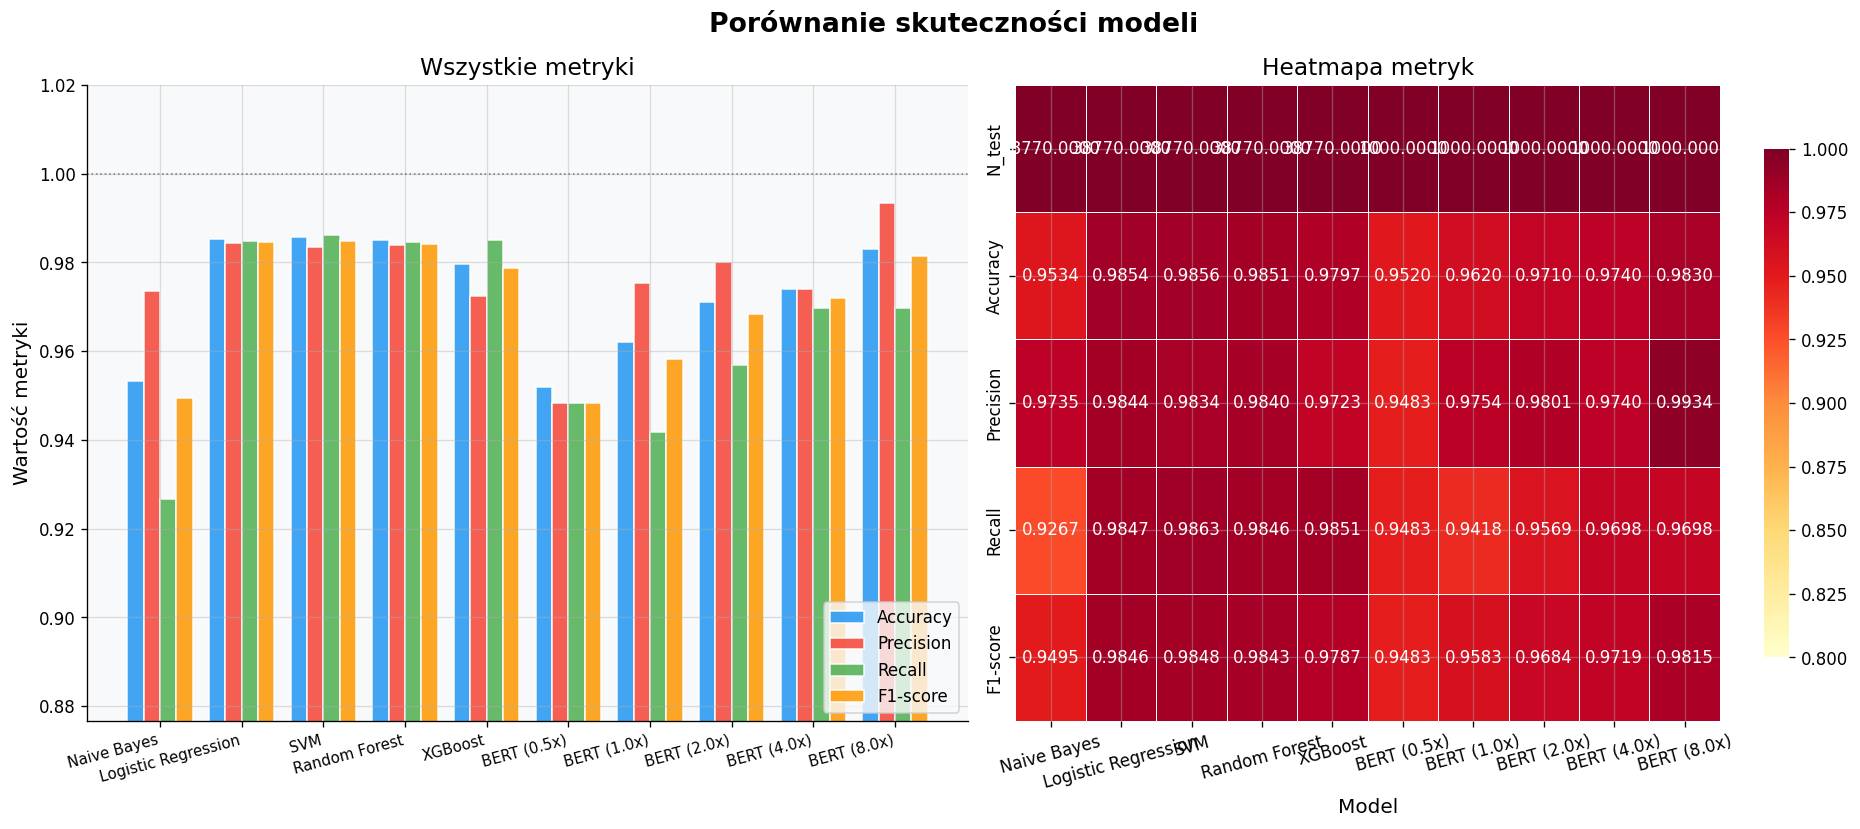

✅ Zapisano: model_comparison.png


In [33]:
# --- Wykres porównawczy (grouped bar) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Porównanie skuteczności modeli', fontsize=16, fontweight='bold')

# Grouped bar
ax = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x     = np.arange(len(results_df))
width = 0.2
for i, (metric, color) in enumerate(zip(metrics, PALETTE)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Wartość metryki')
ax.set_ylim(max(0.0, results_df[metrics].min().min() - 0.05), 1.02)
ax.legend(loc='lower right')
ax.set_title('Wszystkie metryki')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)

# Radar / spider chart — F1 heatmapa
ax2 = axes[1]
hm_data = results_df.T
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, vmin=0.8, vmax=1.0, cbar_kws={'shrink': 0.8})
ax2.set_title('Heatmapa metryk')
ax2.set_xlabel('Model')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Zapisano: model_comparison.png")

## 12. Krzywe ROC i Precision-Recall

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

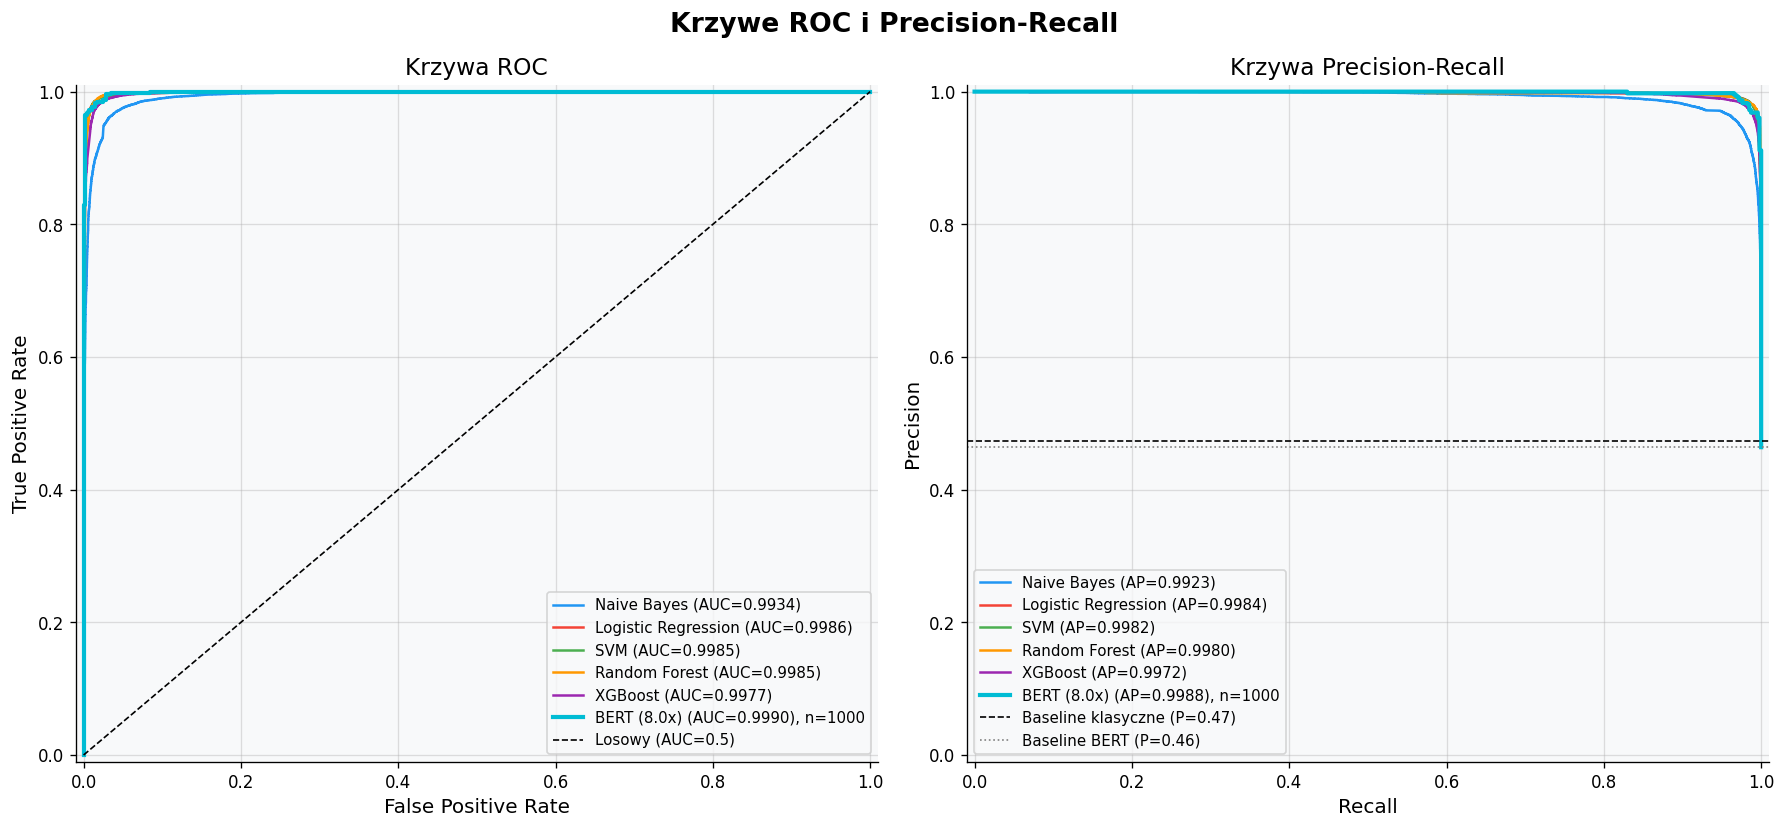

✅ Zapisano: roc_pr_curves.png
BERT: results/bert_finetuned_8p0x | N_test=1000
Klasyczne: N_test=38770


In [47]:
from pathlib import Path
from scipy.special import softmax
from transformers import BertForSequenceClassification

# --- BERT 8.0x: logits na X_test_BERT ---
BERT_8X_DIR = Path("results/bert_finetuned_8p0x")
model_bert_8x = BertForSequenceClassification.from_pretrained(BERT_8X_DIR)
trainer_8x = build_trainer(model_bert_8x, train_dataset_BERT, eval_ds=test_dataset_BERT)
pred_8x = trainer_8x.predict(test_dataset_BERT)
y_bert_prob = softmax(pred_8x.predictions, axis=1)[:, 1]

# --- Klasyczne modele: proba na X_test ---
y_nb_prob  = best_nb.predict_proba(X_test_tfidf)[:, 1]
y_lr_prob  = best_lr.predict_proba(X_test_tfidf)[:, 1]
y_svm_prob = best_svm.predict_proba(X_test_tfidf)[:, 1]
y_rf_prob  = best_rf.predict_proba(X_test_tfidf)[:, 1]
y_xgb_prob = best_xgb.predict_proba(X_test_tfidf)[:, 1]

proba_dict = {
    'Naive Bayes':         y_nb_prob,
    'Logistic Regression': y_lr_prob,
    'SVM':                 y_svm_prob,
    'Random Forest':       y_rf_prob,
    'XGBoost':             y_xgb_prob,
    'BERT (8.0x)':         y_bert_prob,
}

y_true_dict = {
    'Naive Bayes':         y_test,
    'Logistic Regression': y_test,
    'SVM':                 y_test,
    'Random Forest':       y_test,
    'XGBoost':             y_test,
    'BERT (8.0x)':         y_test_BERT,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Krzywe ROC i Precision-Recall', fontsize=16, fontweight='bold')

# --- ROC ---
ax = axes[0]
for (name, prob), color in zip(proba_dict.items(), PALETTE):
    y_true = y_true_dict[name]
    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if 'BERT' in name else 1.5
    label = f'{name} (AUC={roc_auc:.4f})'
    if 'BERT' in name:
        label += f', n={len(y_true)}'
    ax.plot(fpr, tpr, color=color, linewidth=lw, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Losowy (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Krzywa ROC')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

# --- Precision-Recall ---
ax = axes[1]
for (name, prob), color in zip(proba_dict.items(), PALETTE):
    y_true = y_true_dict[name]
    prec, rec, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)
    lw = 2.5 if 'BERT' in name else 1.5
    label = f'{name} (AP={ap:.4f})'
    if 'BERT' in name:
        label += f', n={len(y_true)}'
    ax.plot(rec, prec, color=color, linewidth=lw, label=label)

baseline_classic = y_test.mean()
baseline_bert = y_test_BERT.mean()
ax.axhline(baseline_classic, color='k', linestyle='--', linewidth=1,
           label=f'Baseline klasyczne (P={baseline_classic:.2f})')
ax.axhline(baseline_bert, color='gray', linestyle=':', linewidth=1,
           label=f'Baseline BERT (P={baseline_bert:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Krzywa Precision-Recall')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Zapisano: roc_pr_curves.png")
print(f"BERT: results/bert_finetuned_8p0x | N_test={len(y_test_BERT)}")
print(f"Klasyczne: N_test={len(y_test)}")

## 13. Analiza błędów — False Positives / False Negatives

In [49]:
from pathlib import Path
from transformers import BertForSequenceClassification

def analyze_errors(y_true, y_pred, X_data, model_name, n=3):
    y_true = pd.Series(np.asarray(y_true)).reset_index(drop=True)
    y_pred = np.asarray(y_pred)
    X_data = pd.Series(np.asarray(X_data)).reset_index(drop=True)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{'='*55}")
    print(f"Model: {model_name}")
    print(f"{'='*55}")
    print(f"  True Positive  (poprawnie spam):     {tp}")
    print(f"  True Negative  (poprawnie nie-spam): {tn}")
    print(f"  False Positive (ham → spam):         {fp}  ⚠️ fałszywy alarm")
    print(f"  False Negative (spam → ham):         {fn}  ⚠️ pominięty spam")

    fp_idx = np.array((y_true.values == 0) & (y_pred == 1))
    fn_idx = np.array((y_true.values == 1) & (y_pred == 0))

    fp_examples = X_data.values[fp_idx][:n]
    fn_examples = X_data.values[fn_idx][:n]

    if len(fp_examples):
        print(f"\n  Przykłady FP (ham sklasyfikowany jako spam):")
        for i, ex in enumerate(fp_examples, 1):
            print(f"    {i}. {ex[:120]}...")
    if len(fn_examples):
        print(f"\n  Przykłady FN (spam pominięty):")
        for i, ex in enumerate(fn_examples, 1):
            print(f"    {i}. {ex[:120]}...")


# Wspólny test = te same maile dla NB/LR/SVM/RF/XGB/BERT
X_err = X_test_BERT.reset_index(drop=True)
y_err = y_test_BERT.reset_index(drop=True)
X_err_tfidf = tfidf.transform(X_err)

# BERT 8.0x — jawnie z checkpointu
BERT_8X_DIR = Path("results/bert_finetuned_8p0x")
model_bert_8x = BertForSequenceClassification.from_pretrained(BERT_8X_DIR)
trainer_8x = build_trainer(model_bert_8x, train_dataset_BERT, eval_ds=test_dataset_BERT)
pred_8x = trainer_8x.predict(test_dataset_BERT)
y_pred_bert = np.argmax(pred_8x.predictions, axis=1)

err_preds = {
    'Naive Bayes':         best_nb.predict(X_err_tfidf),
    'Logistic Regression': best_lr.predict(X_err_tfidf),
    'SVM':                 best_svm.predict(X_err_tfidf),
    'Random Forest':       best_rf.predict(X_err_tfidf),
    'XGBoost':             best_xgb.predict(X_err_tfidf),
    'BERT (8.0x)':         np.asarray(y_pred_bert),
}

assert len(y_pred_bert) == len(y_err), "BERT i klasyczne modele muszą mieć tę samą N_test"

print(f"Analiza błędów na wspólnym teście: N={len(y_err)}")
print(f"BERT: {BERT_8X_DIR}")
for model_name, preds in err_preds.items():
    analyze_errors(y_err, preds, X_err, model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Analiza błędów na wspólnym teście: N=1000
BERT: results\bert_finetuned_8p0x

Model: Naive Bayes
  True Positive  (poprawnie spam):     427
  True Negative  (poprawnie nie-spam): 526
  False Positive (ham → spam):         10  ⚠️ fałszywy alarm
  False Negative (spam → ham):         37  ⚠️ pominięty spam

  Przykłady FP (ham sklasyfikowany jako spam):
    1. hey guys telephone number residence new place escapenumber escapenumber escapenumber number escapenumber escapenumber es...
    2. ok nice day e chat friends online try msn messenger http messenger msn com...
    3. susan request info electronic funds deposited four star money asked send fourstar deposit slips leonard...

  Przykłady FN (spam pominięty):
    1. investor alert make escapenumber fully secured learn make escapenumber paid quarterly advance factoring commercial accou...
    2. caon takes new direction investors are all over it chan on international inc symbol caon close escapenumber escapenumber...
    3. the ldc forum d

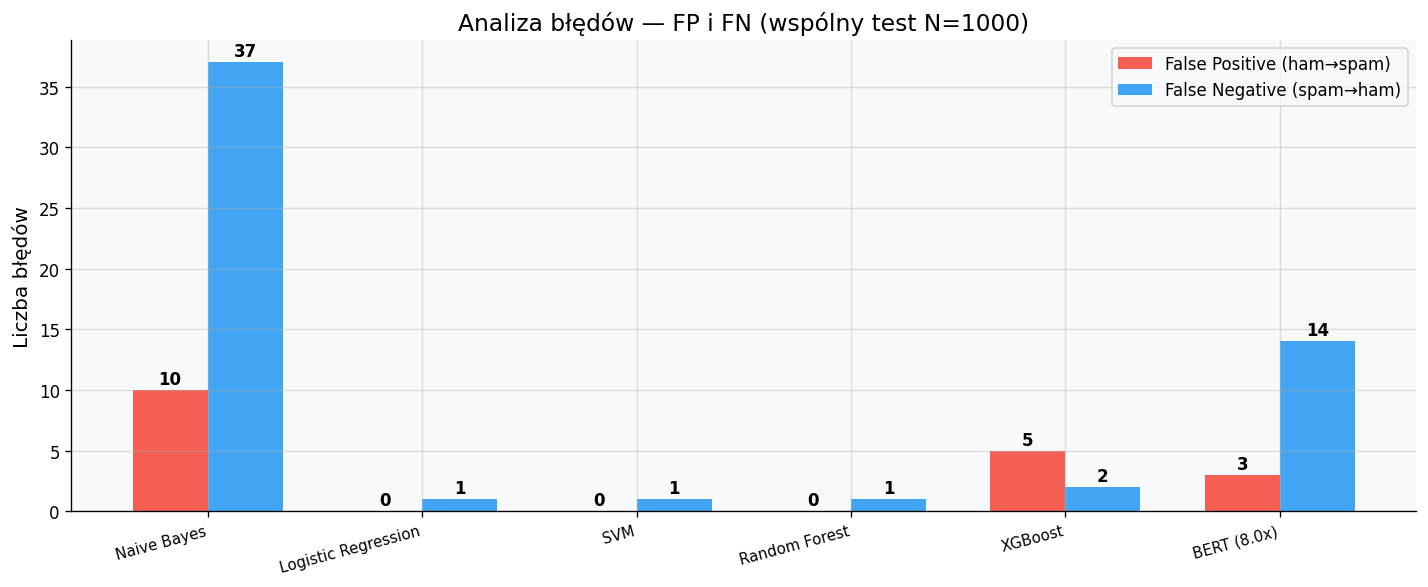

In [50]:
# --- Wykres FP/FN (ten sam zbiór co analyze_errors) ---
fp_counts, fn_counts = [], []
model_names_err = list(err_preds.keys())

for name, preds in err_preds.items():
    cm = confusion_matrix(y_err, preds)
    tn, fp, fn, tp = cm.ravel()
    fp_counts.append(fp)
    fn_counts.append(fn)

x = np.arange(len(model_names_err))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, fp_counts, width, label='False Positive (ham→spam)', color=PALETTE[1], alpha=0.85)
b2 = ax.bar(x + width/2, fn_counts, width, label='False Negative (spam→ham)', color=PALETTE[0], alpha=0.85)
for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)), ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_err, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Liczba błędów')
ax.set_title(f'Analiza błędów — FP i FN (wspólny test N={len(y_err)})')
ax.legend()
plt.tight_layout()
plt.savefig('fp_fn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()